In [35]:
# ============================================================
# STEP 1 — PREPROCESSING ENVIRONMENT SETUP
# ============================================================

from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torchvision
from torchvision import transforms

print("Preprocessing environment ready")
print("Python executable:", os.sys.executable)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

Preprocessing environment ready
Python executable: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\.venv\Scripts\python.exe
PyTorch: 2.14.0+cpu
Torchvision: 0.29.0+cpu


In [36]:
# ============================================================
# STEP 2 — DATASET PATHS
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATASET_ROOT = (
    PROJECT_ROOT
    / "dataset"
    / "GroceryStoreDataset-master"
    / "dataset"
)

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

CLASSES_CSV = DATASET_ROOT / "classes.csv"

print("Project root :", PROJECT_ROOT)
print("Dataset root :", DATASET_ROOT)

print("\nChecking dataset paths...")

for name, path in {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR,
    "Classes CSV": CLASSES_CSV,
}.items():
    print(f"{'OK' if path.exists() else 'MISSING':8} {name}: {path}")

Project root : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification
Dataset root : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset

Checking dataset paths...
OK       Train: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\train
OK       Validation: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\val
OK       Test: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\test
OK       Classes CSV: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\classes.csv


#Load the class metadata

In [37]:
# ============================================================
# STEP 3 — LOAD CLASS METADATA
# ============================================================

classes_df = pd.read_csv(CLASSES_CSV)

print("Classes CSV loaded successfully")
print("Shape:", classes_df.shape)

print("\nColumns:")
print(classes_df.columns.tolist())

print("\nFirst 10 classes:")
display(
    classes_df[
        [
            "Class Name (str)",
            "Class ID (int)",
            "Coarse Class Name (str)",
            "Coarse Class ID (int)"
        ]
    ].head(10)
)

# Basic validation
assert classes_df["Class ID (int)"].nunique() == 81
assert classes_df["Class ID (int)"].min() == 0
assert classes_df["Class ID (int)"].max() == 80

print("\nFine-grained classes:", classes_df["Class ID (int)"].nunique())
print(
    "Coarse-grained categories:",
    classes_df["Coarse Class ID (int)"].nunique()
)
print("Class metadata validation: PASSED")

Classes CSV loaded successfully
Shape: (81, 6)

Columns:
['Class Name (str)', 'Class ID (int)', 'Coarse Class Name (str)', 'Coarse Class ID (int)', 'Iconic Image Path (str)', 'Product Description Path (str)']

First 10 classes:


,Class Name (str),Class ID (int),Coarse Class Name (str),Coarse Class ID (int)
0,Golden-Delicious,0,Apple,0
1,Granny-Smith,1,Apple,0
2,Pink-Lady,2,Apple,0
3,Red-Delicious,3,Apple,0
4,Royal-Gala,4,Apple,0
5,Avocado,5,Avocado,1
6,Banana,6,Banana,2
7,Kiwi,7,Kiwi,3
8,Lemon,8,Lemon,4
9,Lime,9,Lime,5



Fine-grained classes: 81
Coarse-grained categories: 43
Class metadata validation: PASSED


#Load train, validation, and test labels

In [38]:
# ============================================================
# STEP 4 — LOAD DATASET LABEL FILES
# ============================================================

LABEL_COLUMNS = [
    "image_path",
    "fine_class_id",
    "coarse_class_id"
]

train_df = pd.read_csv(
    DATASET_ROOT / "train.txt",
    header=None,
    names=LABEL_COLUMNS
)

val_df = pd.read_csv(
    DATASET_ROOT / "val.txt",
    header=None,
    names=LABEL_COLUMNS
)

test_df = pd.read_csv(
    DATASET_ROOT / "test.txt",
    header=None,
    names=LABEL_COLUMNS
)

print("Dataset label files loaded successfully\n")

print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)

print("\nTotal images:",
      len(train_df) + len(val_df) + len(test_df))

print("\nTrain sample:")
display(train_df.head())

print("\nValidation sample:")
display(val_df.head())

print("\nTest sample:")
display(test_df.head())

Dataset label files loaded successfully

Train      : (2640, 3)
Validation : (296, 3)
Test       : (2485, 3)

Total images: 5421

Train sample:


,image_path,fine_class_id,coarse_class_id
0,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0
1,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0
2,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0
3,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0
4,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0



Validation sample:


,image_path,fine_class_id,coarse_class_id
0,val/Fruit/Apple/Golden-Delicious/Golden-Delici...,0,0
1,val/Fruit/Apple/Golden-Delicious/Golden-Delici...,0,0
2,val/Fruit/Apple/Golden-Delicious/Golden-Delici...,0,0
3,val/Fruit/Apple/Golden-Delicious/Golden-Delici...,0,0
4,val/Fruit/Apple/Golden-Delicious/Golden-Delici...,0,0



Test sample:


,image_path,fine_class_id,coarse_class_id
0,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0
1,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0
2,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0
3,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0
4,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0


Verify label consistency

In [39]:
# ============================================================
# STEP 5 — LABEL CONSISTENCY VALIDATION
# ============================================================

print("=" * 70)
print("LABEL CONSISTENCY VALIDATION")
print("=" * 70)

# Create fine → coarse mapping from classes.csv
fine_to_coarse = dict(
    zip(
        classes_df["Class ID (int)"],
        classes_df["Coarse Class ID (int)"]
    )
)

for split_name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    
    # Check fine-class IDs
    invalid_fine = ~df["fine_class_id"].isin(
        classes_df["Class ID (int)"]
    )
    
    # Check coarse-class IDs
    invalid_coarse = ~df["coarse_class_id"].isin(
        classes_df["Coarse Class ID (int)"]
    )
    
    # Check fine → coarse relationship
    mapping_errors = df.apply(
        lambda row: fine_to_coarse.get(row["fine_class_id"])
        != row["coarse_class_id"],
        axis=1
    )
    
    print(f"\n{split_name}")
    print("-" * 70)
    print("Invalid fine-class IDs   :", invalid_fine.sum())
    print("Invalid coarse-class IDs :", invalid_coarse.sum())
    print("Fine → coarse errors     :", mapping_errors.sum())

print("\n" + "=" * 70)
print("LABEL VALIDATION COMPLETED")
print("=" * 70)

LABEL CONSISTENCY VALIDATION

Train
----------------------------------------------------------------------
Invalid fine-class IDs   : 0
Invalid coarse-class IDs : 0
Fine → coarse errors     : 0

Validation
----------------------------------------------------------------------
Invalid fine-class IDs   : 0
Invalid coarse-class IDs : 0
Fine → coarse errors     : 0

Test
----------------------------------------------------------------------
Invalid fine-class IDs   : 0
Invalid coarse-class IDs : 0
Fine → coarse errors     : 0

LABEL VALIDATION COMPLETED


Inspect actual training images


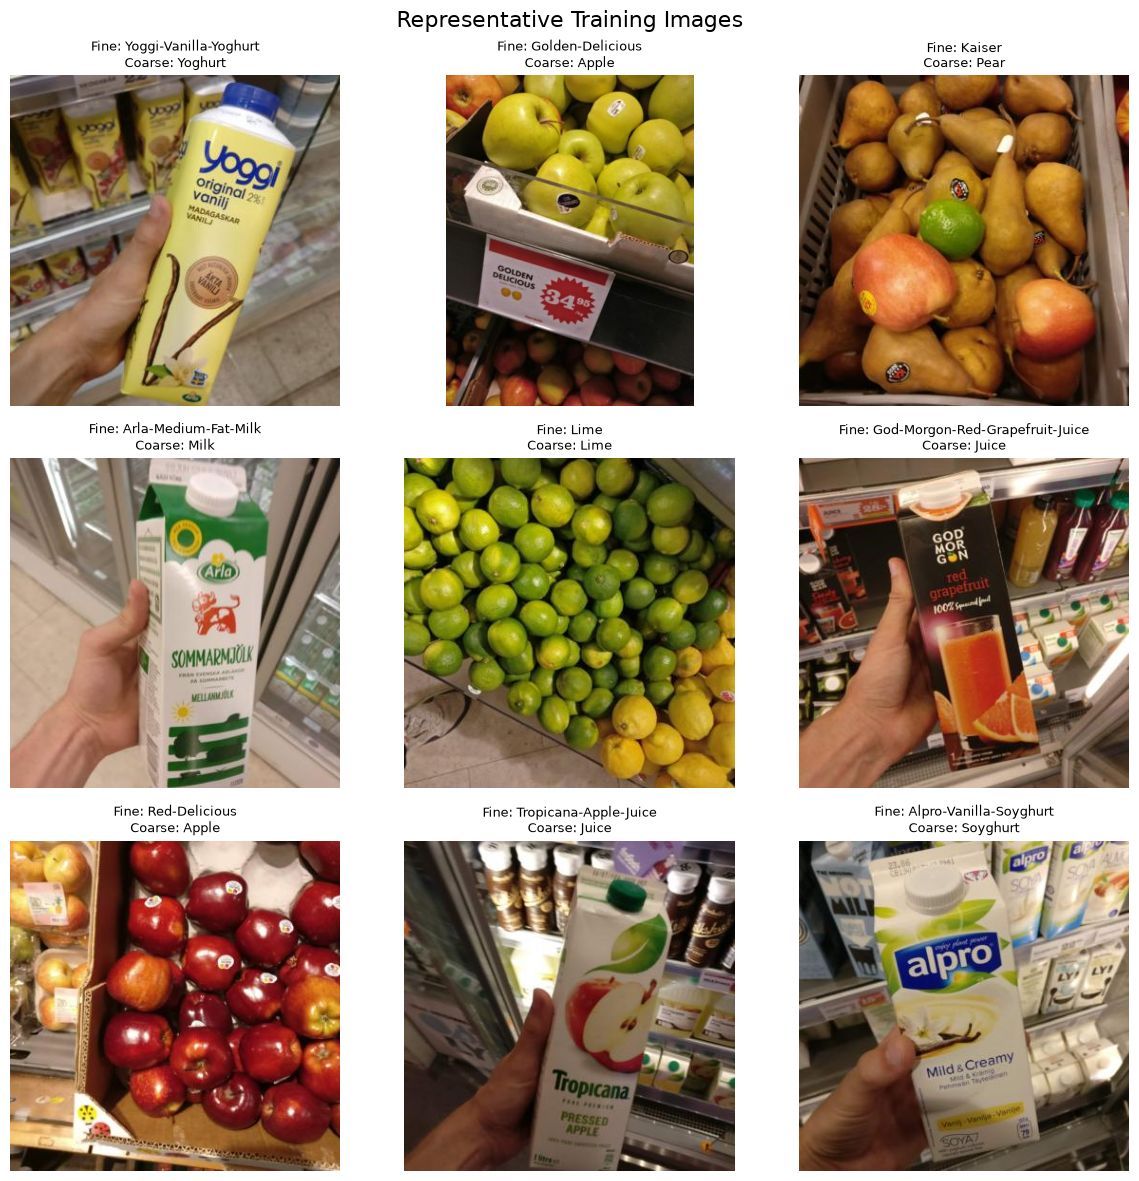

In [40]:
# ============================================================
# STEP 6 — VISUAL INSPECTION OF TRAINING IMAGES
# ============================================================

# Select 9 representative training samples
sample_df = train_df.sample(
    n=9,
    random_state=42
).reset_index(drop=True)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):

    # image_path already contains "train/..."
    image_path = DATASET_ROOT / row["image_path"]

    image = Image.open(image_path).convert("RGB")

    fine_id = int(row["fine_class_id"])
    coarse_id = int(row["coarse_class_id"])

    fine_name = classes_df.loc[
        classes_df["Class ID (int)"] == fine_id,
        "Class Name (str)"
    ].iloc[0]

    coarse_name = classes_df.loc[
        classes_df["Coarse Class ID (int)"] == coarse_id,
        "Coarse Class Name (str)"
    ].iloc[0]

    ax.imshow(image)
    ax.set_title(
        f"Fine: {fine_name}\nCoarse: {coarse_name}",
        fontsize=9
    )
    ax.axis("off")

plt.suptitle(
    "Representative Training Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

STEP 3: Define preprocessing and augmentation

In [41]:
# ============================================================
# STEP 1 — IMPORTS AND ENVIRONMENT
# ============================================================

from pathlib import Path
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

print("Preprocessing notebook initialized")
print("Python executable:", sys.executable)
print("PyTorch:", torch.__version__)

Preprocessing notebook initialized
Python executable: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\.venv\Scripts\python.exe
PyTorch: 2.14.0+cpu


In [42]:
# ============================================================
# STEP 2 — DATASET PATHS
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATASET_ROOT = (
    PROJECT_ROOT
    / "dataset"
    / "GroceryStoreDataset-master"
    / "dataset"
)

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

CLASSES_CSV = DATASET_ROOT / "classes.csv"

print("Project root :", PROJECT_ROOT)
print("Dataset root :", DATASET_ROOT)

print("\nChecking dataset paths...")

assert DATASET_ROOT.exists(), "Dataset root not found"
assert TRAIN_DIR.exists(), "Training directory not found"
assert VAL_DIR.exists(), "Validation directory not found"
assert TEST_DIR.exists(), "Test directory not found"
assert CLASSES_CSV.exists(), "classes.csv not found"

print("Train      :", TRAIN_DIR, "OK")
print("Validation :", VAL_DIR, "OK")
print("Test       :", TEST_DIR, "OK")
print("Classes CSV:", CLASSES_CSV, "OK")

Project root : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification
Dataset root : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset

Checking dataset paths...
Train      : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\train OK
Validation : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\val OK
Test       : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\test OK
Classes CSV: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\classes.csv OK


In [43]:
# ============================================================
# STEP 3 — IMAGE PREPROCESSING AND AUGMENTATION
# ============================================================

IMAGE_SIZE = 224

# ImageNet normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# ------------------------------------------------------------
# Training transformations
# ------------------------------------------------------------

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(
    degrees=10,
    fill=(128, 128, 128)
),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.03
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# Validation transformations
# ------------------------------------------------------------

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# Test transformations
# ------------------------------------------------------------

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


print("Image preprocessing configured successfully")
print("Target image size:", IMAGE_SIZE, "x", IMAGE_SIZE)

print("\nTraining transformations:")
print(train_transform)

print("\nValidation transformations:")
print(val_transform)

print("\nTest transformations:")
print(test_transform)

Image preprocessing configured successfully
Target image size: 224 x 224

Training transformations:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=(128, 128, 128))
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.85, 1.15), hue=(-0.03, 0.03))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation transformations:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Test transformations:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [44]:
# ============================================================
# STEP 4 — TEST PREPROCESSING ON A REAL IMAGE
# ============================================================

# Get one image from the training directory
sample_image_path = next(TRAIN_DIR.rglob("*.jpg"))

print("Sample image:")
print(sample_image_path)

# Open original image
original_image = Image.open(sample_image_path).convert("RGB")

# Apply training preprocessing
processed_image = train_transform(original_image)

print("\nOriginal size :", original_image.size)
print("Processed size:", tuple(processed_image.shape))
print("Processed dtype:", processed_image.dtype)

Sample image:
c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\train\Vegetables\Asparagus\Asparagus_001.jpg

Original size : (348, 464)
Processed size: (3, 224, 224)
Processed dtype: torch.float32


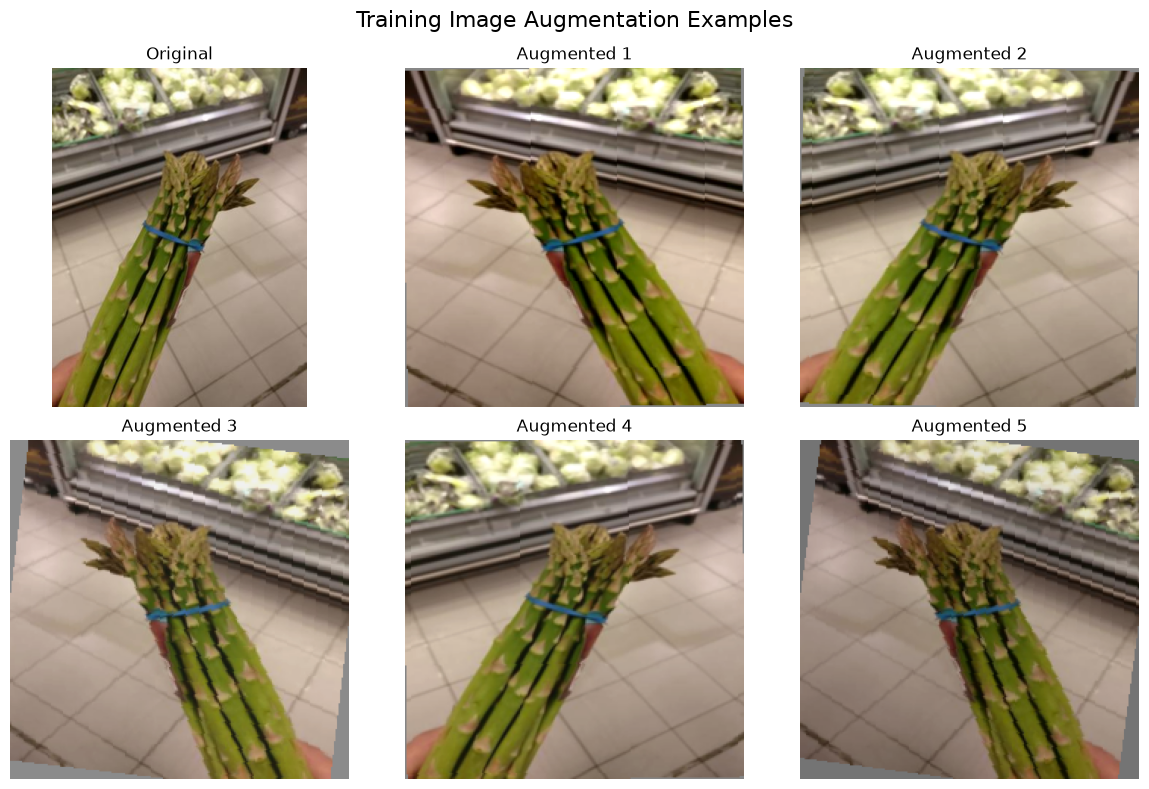

In [45]:
# ============================================================
# STEP 5 — VISUALIZE AUGMENTATION
# ============================================================

def denormalize(tensor):
    """
    Convert a normalized tensor back to displayable RGB values.
    """
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    image = tensor * std + mean
    image = torch.clamp(image, 0, 1)

    return image


fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Original image
axes[0, 0].imshow(original_image)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

# Generate augmented versions
for i in range(5):
    augmented = train_transform(original_image)
    display_image = denormalize(augmented)
    display_image = display_image.permute(1, 2, 0).numpy()

    ax = axes.flat[i + 1]
    ax.imshow(display_image)
    ax.set_title(f"Augmented {i + 1}")
    ax.axis("off")

plt.suptitle(
    "Training Image Augmentation Examples",
    fontsize=16
)

plt.tight_layout()
plt.show()

STEP 4 — DATASET AND DATALOADERS

In [46]:
# ============================================================
# STEP 4 — PYTORCH DATASET AND DATALOADER PREPARATION
# ============================================================

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path
import torch

print("PyTorch Dataset/DataLoader imports successful")
print("PyTorch version:", torch.__version__)

PyTorch Dataset/DataLoader imports successful
PyTorch version: 2.14.0+cpu


In [47]:
# ============================================================
# STEP 4 — CELL 2
# CUSTOM GROCERY DATASET
# ============================================================

class GroceryProductDataset(Dataset):

    def __init__(self, dataframe, dataset_root, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.dataset_root = Path(dataset_root)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        # Full image path
        image_path = self.dataset_root / row["image_path"]

        # Load image and ensure RGB format
        image = Image.open(image_path).convert("RGB")

        # Apply preprocessing / augmentation
        if self.transform is not None:
            image = self.transform(image)

        # Fine-grained class label
        fine_label = int(row["fine_class_id"])

        # Coarse-grained category label
        coarse_label = int(row["coarse_class_id"])

        return image, fine_label, coarse_label


print("GroceryProductDataset class created successfully")

GroceryProductDataset class created successfully


In [48]:
# ============================================================
# STEP 4 — CELL 3
# CREATE TRAIN / VALIDATION / TEST DATASETS
# ============================================================

train_dataset = GroceryProductDataset(
    dataframe=train_df,
    dataset_root=DATASET_ROOT,
    transform=train_transform
)

val_dataset = GroceryProductDataset(
    dataframe=val_df,
    dataset_root=DATASET_ROOT,
    transform=val_transform
)

test_dataset = GroceryProductDataset(
    dataframe=test_df,
    dataset_root=DATASET_ROOT,
    transform=test_transform
)

print("Dataset objects created successfully")
print("------------------------------------")
print("Training dataset   :", len(train_dataset))
print("Validation dataset :", len(val_dataset))
print("Test dataset       :", len(test_dataset))

Dataset objects created successfully
------------------------------------
Training dataset   : 2640
Validation dataset : 296
Test dataset       : 2485


In [49]:
# ============================================================
# STEP 4 — CELL 4
# VERIFY A SINGLE DATASET SAMPLE
# ============================================================

sample_image, sample_fine_label, sample_coarse_label = train_dataset[0]

print("Single dataset sample loaded successfully")
print("------------------------------------------")
print("Image type        :", type(sample_image))
print("Image shape       :", sample_image.shape)
print("Image dtype       :", sample_image.dtype)
print("Fine class ID     :", sample_fine_label)
print("Coarse class ID   :", sample_coarse_label)
print("Image value range :", 
      f"{sample_image.min().item():.4f} to {sample_image.max().item():.4f}")

Single dataset sample loaded successfully
------------------------------------------
Image type        : <class 'torch.Tensor'>
Image shape       : torch.Size([3, 224, 224])
Image dtype       : torch.float32
Fine class ID     : 0
Coarse class ID   : 0
Image value range : -2.1179 to 1.7865


In [53]:
# ============================================================
# STEP 4 — CELL 5
# CREATE TRAIN / VALIDATION / TEST DATALOADERS
# ============================================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created successfully")
print("---------------------------------")
print("Batch size        :", BATCH_SIZE)
print("Training batches  :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches      :", len(test_loader))

DataLoaders created successfully
---------------------------------
Batch size        : 32
Training batches  : 83
Validation batches: 10
Test batches      : 78


In [51]:
# ============================================================
# STEP 4 — CELL 6
# VERIFY ONE COMPLETE TRAINING BATCH
# ============================================================

images, fine_labels, coarse_labels = next(iter(train_loader))

print("Training batch loaded successfully")
print("-----------------------------------")
print("Images shape       :", images.shape)
print("Images dtype       :", images.dtype)
print("Fine labels shape  :", fine_labels.shape)
print("Fine labels dtype  :", fine_labels.dtype)
print("Coarse labels shape:", coarse_labels.shape)
print("Coarse labels dtype:", coarse_labels.dtype)

print("\nFirst 10 fine labels:")
print(fine_labels[:10].tolist())

print("\nFirst 10 coarse labels:")
print(coarse_labels[:10].tolist())

Training batch loaded successfully
-----------------------------------
Images shape       : torch.Size([32, 3, 224, 224])
Images dtype       : torch.float32
Fine labels shape  : torch.Size([32])
Fine labels dtype  : torch.int64
Coarse labels shape: torch.Size([32])
Coarse labels dtype: torch.int64

First 10 fine labels:
[15, 64, 78, 14, 46, 21, 0, 66, 22, 68]

First 10 coarse labels:
[8, 33, 41, 7, 23, 13, 0, 35, 13, 37]


In [54]:
# ============================================================
# STEP 4 — CELL 7
# FINAL DATALOADER SANITY CHECK
# ============================================================

def check_loader(loader, loader_name):
    images, fine_labels, coarse_labels = next(iter(loader))

    print(f"{loader_name}")
    print("-" * 50)
    print("Batch image shape :", tuple(images.shape))
    print("Fine labels shape :", tuple(fine_labels.shape))
    print("Coarse labels shape:", tuple(coarse_labels.shape))
    print("Image dtype       :", images.dtype)
    print("Fine label dtype  :", fine_labels.dtype)
    print("Coarse label dtype:", coarse_labels.dtype)
    print()


check_loader(train_loader, "TRAINING")
check_loader(val_loader, "VALIDATION")
check_loader(test_loader, "TEST")

print("FINAL DATALOADER SANITY CHECK PASSED")

TRAINING
--------------------------------------------------
Batch image shape : (32, 3, 224, 224)
Fine labels shape : (32,)
Coarse labels shape: (32,)
Image dtype       : torch.float32
Fine label dtype  : torch.int64
Coarse label dtype: torch.int64

VALIDATION
--------------------------------------------------
Batch image shape : (32, 3, 224, 224)
Fine labels shape : (32,)
Coarse labels shape: (32,)
Image dtype       : torch.float32
Fine label dtype  : torch.int64
Coarse label dtype: torch.int64

TEST
--------------------------------------------------
Batch image shape : (32, 3, 224, 224)
Fine labels shape : (32,)
Coarse labels shape: (32,)
Image dtype       : torch.float32
Fine label dtype  : torch.int64
Coarse label dtype: torch.int64

FINAL DATALOADER SANITY CHECK PASSED


STEP 5 — MODEL ARCHITECTURE

In [55]:
# ============================================================
# STEP 5 — MODEL ARCHITECTURE
# CELL 1 — MODEL CONFIGURATION
# ============================================================

NUM_CLASSES = 81
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Model configuration")
print("-------------------")
print("Number of fine-grained classes:", NUM_CLASSES)
print("Training device:", DEVICE)

Model configuration
-------------------
Number of fine-grained classes: 81
Training device: cpu


In [28]:
# ============================================================
# STEP 5 — CELL 2
# LOAD PRETRAINED RESNET-50
# ============================================================

from torchvision.models import resnet50, ResNet50_Weights

# Load ImageNet-pretrained ResNet-50
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

print("Pretrained ResNet-50 loaded successfully")
print("-----------------------------------------")
print("Original output classes:", model.fc.out_features)
print("Model type:", type(model).__name__)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100.0%


Pretrained ResNet-50 loaded successfully
-----------------------------------------
Original output classes: 1000
Model type: ResNet


In [56]:
# ============================================================
# STEP 5 — CELL 3
# MODIFY RESNET-50 FOR 81 PRODUCT CLASSES
# ============================================================

import torch.nn as nn

# Get the number of input features to the original classifier
num_features = model.fc.in_features

# Replace the original ImageNet classifier
model.fc = nn.Linear(
    in_features=num_features,
    out_features=NUM_CLASSES
)

# Move model to the selected device
model = model.to(DEVICE)

print("ResNet-50 classification layer modified successfully")
print("-----------------------------------------------------")
print("Classifier input features :", num_features)
print("Classifier output classes:", model.fc.out_features)
print("Model device              :", DEVICE)
print("Final classifier          :", model.fc)

ResNet-50 classification layer modified successfully
-----------------------------------------------------
Classifier input features : 2048
Classifier output classes: 81
Model device              : cpu
Final classifier          : Linear(in_features=2048, out_features=81, bias=True)


In [30]:
# ============================================================
# STEP 5 — CELL 4
# INSPECT MODEL PARAMETERS
# ============================================================

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("MODEL PARAMETER SUMMARY")
print("=" * 60)
print("Total parameters     :", f"{total_parameters:,}")
print("Trainable parameters :", f"{trainable_parameters:,}")
print("Frozen parameters    :", f"{total_parameters - trainable_parameters:,}")

print("\nFinal classifier:")
print(model.fc)

MODEL PARAMETER SUMMARY
Total parameters     : 23,674,001
Trainable parameters : 23,674,001
Frozen parameters    : 0

Final classifier:
Linear(in_features=2048, out_features=81, bias=True)


In [57]:
# ============================================================
# STEP 5 — CELL 5
# FREEZE RESNET-50 BACKBONE
# ============================================================

# Freeze all model parameters
for parameter in model.parameters():
    parameter.requires_grad = False

# Keep the new classification layer trainable
for parameter in model.fc.parameters():
    parameter.requires_grad = True


# Count parameters after freezing
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

frozen_parameters = total_parameters - trainable_parameters


print("TRANSFER LEARNING FREEZING CONFIGURED")
print("=" * 60)
print("Total parameters     :", f"{total_parameters:,}")
print("Trainable parameters :", f"{trainable_parameters:,}")
print("Frozen parameters    :", f"{frozen_parameters:,}")

print("\nTrainable layer:")
print("model.fc")
print(model.fc)

TRANSFER LEARNING FREEZING CONFIGURED
Total parameters     : 23,674,001
Trainable parameters : 165,969
Frozen parameters    : 23,508,032

Trainable layer:
model.fc
Linear(in_features=2048, out_features=81, bias=True)


In [58]:
# ============================================================
# STEP 5 — CELL 6
# VERIFY PARAMETER FREEZING
# ============================================================

print("TRAINABLE PARAMETERS")
print("=" * 60)

trainable_layers = []

for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        trainable_layers.append(name)
        print(name)

print("\nTotal trainable parameter tensors:", len(trainable_layers))

# Verify that every trainable parameter belongs to the classifier
only_classifier_trainable = all(
    name.startswith("fc.")
    for name in trainable_layers
)

print("\nOnly classifier is trainable:", only_classifier_trainable)

# Verify that the backbone is frozen
backbone_frozen = all(
    not parameter.requires_grad
    for name, parameter in model.named_parameters()
    if not name.startswith("fc.")
)

print("Backbone is completely frozen:", backbone_frozen)

if only_classifier_trainable and backbone_frozen:
    print("\nPARAMETER FREEZING CHECK PASSED")
else:
    print("\nPARAMETER FREEZING CHECK FAILED")

TRAINABLE PARAMETERS
fc.weight
fc.bias

Total trainable parameter tensors: 2

Only classifier is trainable: True
Backbone is completely frozen: True

PARAMETER FREEZING CHECK PASSED


In [59]:
# ============================================================
# STEP 5 — CELL 7
# FORWARD-PASS SANITY CHECK
# ============================================================

# Get one batch from the training DataLoader
images, fine_labels, coarse_labels = next(iter(train_loader))

# Move images to the selected device
images = images.to(DEVICE)

# Evaluation mode for this technical check
model.eval()

# Disable gradient calculation
with torch.no_grad():
    outputs = model(images)

print("FORWARD-PASS SANITY CHECK")
print("=" * 60)
print("Input shape        :", tuple(images.shape))
print("Output shape       :", tuple(outputs.shape))
print("Output dtype       :", outputs.dtype)
print("Expected classes   :", NUM_CLASSES)

# Verify output dimensions
expected_shape = (images.shape[0], NUM_CLASSES)

print("\nExpected output shape:", expected_shape)
print("Actual output shape  :", tuple(outputs.shape))

if tuple(outputs.shape) == expected_shape:
    print("\nFORWARD-PASS CHECK PASSED")
else:
    print("\nFORWARD-PASS CHECK FAILED")

FORWARD-PASS SANITY CHECK
Input shape        : (32, 3, 224, 224)
Output shape       : (32, 81)
Output dtype       : torch.float32
Expected classes   : 81

Expected output shape: (32, 81)
Actual output shape  : (32, 81)

FORWARD-PASS CHECK PASSED


In [60]:
# ============================================================
# STEP 5 — CELL 8
# CLASSIFICATION LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()

# Use the previously generated batch
# Model is already in evaluation mode from the forward-pass test

with torch.no_grad():
    loss = criterion(outputs, fine_labels.to(DEVICE))

print("LOSS FUNCTION CONFIGURED")
print("=" * 60)
print("Loss function:", criterion)
print("Model output shape:", tuple(outputs.shape))
print("Fine-label shape:", tuple(fine_labels.shape))
print("Initial batch loss:", f"{loss.item():.6f}")

if torch.isfinite(loss):
    print("\nLOSS SANITY CHECK PASSED")
else:
    print("\nLOSS SANITY CHECK FAILED")

LOSS FUNCTION CONFIGURED
Loss function: CrossEntropyLoss()
Model output shape: (32, 81)
Fine-label shape: (32,)
Initial batch loss: 4.446953

LOSS SANITY CHECK PASSED


In [61]:
# ============================================================
# STEP 5 — CELL 9
# OPTIMIZER CONFIGURATION
# ============================================================

LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        model.parameters()
    ),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("OPTIMIZER CONFIGURED")
print("=" * 60)
print("Optimizer     :", optimizer.__class__.__name__)
print("Learning rate :", LEARNING_RATE)
print("Weight decay  :", WEIGHT_DECAY)

# Verify optimizer only contains trainable parameters
optimizer_parameters = sum(
    parameter.numel()
    for group in optimizer.param_groups
    for parameter in group["params"]
)

print("Optimizer parameters:", f"{optimizer_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")

if optimizer_parameters == trainable_parameters:
    print("\nOPTIMIZER PARAMETER CHECK PASSED")
else:
    print("\nOPTIMIZER PARAMETER CHECK FAILED")

OPTIMIZER CONFIGURED
Optimizer     : AdamW
Learning rate : 0.001
Weight decay  : 0.0001
Optimizer parameters: 165,969
Trainable parameters: 165,969

OPTIMIZER PARAMETER CHECK PASSED


In [62]:
# ============================================================
# STEP 5 — CELL 10
# LEARNING-RATE SCHEDULER
# ============================================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

print("LEARNING-RATE SCHEDULER CONFIGURED")
print("=" * 60)
print("Scheduler       :", scheduler.__class__.__name__)
print("Mode            : min")
print("Reduction factor:", 0.1)
print("Patience        :", 2)

print("\nSCHEDULER CONFIGURATION CHECK PASSED")

LEARNING-RATE SCHEDULER CONFIGURED
Scheduler       : ReduceLROnPlateau
Mode            : min
Reduction factor: 0.1
Patience        : 2

SCHEDULER CONFIGURATION CHECK PASSED


In [63]:
# ============================================================
# STEP 5 — CELL 11
# TRAINING CONFIGURATION
# ============================================================

NUM_EPOCHS = 10

print("TRAINING CONFIGURATION")
print("=" * 60)
print("Number of epochs :", NUM_EPOCHS)
print("Batch size       :", 32)
print("Learning rate    :", LEARNING_RATE)
print("Weight decay     :", WEIGHT_DECAY)
print("Device           :", DEVICE)
print("Number of classes:", NUM_CLASSES)

print("\nTRAINING CONFIGURATION CHECK PASSED")


TRAINING CONFIGURATION
Number of epochs : 10
Batch size       : 32
Learning rate    : 0.001
Weight decay     : 0.0001
Device           : cpu
Number of classes: 81

TRAINING CONFIGURATION CHECK PASSED


In [67]:
# ============================================================
# STEP 5 — CELL 12
# TRAINING FUNCTION
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Train the model for one complete epoch.

    Returns:
        epoch_loss     : Average training loss
        epoch_accuracy : Training classification accuracy
    """

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, fine_labels, _ in loader:

        # Move data to the selected device
        images = images.to(device)
        fine_labels = fine_labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate classification loss
        loss = criterion(outputs, fine_labels)

        # Backpropagation
        loss.backward()

        # Update trainable parameters
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item() * images.size(0)

        # Calculate predictions
        predictions = outputs.argmax(dim=1)

        # Count correct predictions
        correct += (predictions == fine_labels).sum().item()
        total += fine_labels.size(0)

    # Calculate average loss and accuracy
    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("Training function created successfully")

Training function created successfully


In [68]:
# ============================================================
# STEP 5 — CELL 13
# VALIDATION FUNCTION
# ============================================================

def validate_one_epoch(model, loader, criterion, device):
    """
    Evaluate the model for one complete validation epoch.

    Returns:
        epoch_loss     : Average validation loss
        epoch_accuracy : Validation classification accuracy
    """

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    # Disable gradient calculation during validation
    with torch.no_grad():

        for images, fine_labels, _ in loader:

            # Move data to the selected device
            images = images.to(device)
            fine_labels = fine_labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate validation loss
            loss = criterion(outputs, fine_labels)

            # Accumulate loss
            running_loss += loss.item() * images.size(0)

            # Calculate predictions
            predictions = outputs.argmax(dim=1)

            # Count correct predictions
            correct += (predictions == fine_labels).sum().item()
            total += fine_labels.size(0)

    # Calculate average loss and accuracy
    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("Validation function created successfully")

Validation function created successfully


In [69]:
# ============================================================
# STEP 5 — CELL 14
# ONE-BATCH TRAINING SANITY CHECK
# ============================================================

model.train()

# Get one training batch
images, fine_labels, _ = next(iter(train_loader))

images = images.to(DEVICE)
fine_labels = fine_labels.to(DEVICE)

# Clear gradients
optimizer.zero_grad()

# Forward pass
outputs = model(images)

# Calculate loss
loss = criterion(outputs, fine_labels)

# Backward pass
loss.backward()

# Check gradients of the trainable classifier
fc_weight_gradient = model.fc.weight.grad
fc_bias_gradient = model.fc.bias.grad

print("ONE-BATCH TRAINING SANITY CHECK")
print("=" * 60)
print("Input shape          :", tuple(images.shape))
print("Output shape         :", tuple(outputs.shape))
print("Loss                 :", f"{loss.item():.6f}")

print("\nClassifier gradients:")
print("FC weight gradient exists:", fc_weight_gradient is not None)
print("FC bias gradient exists  :", fc_bias_gradient is not None)

if fc_weight_gradient is not None:
    print("FC weight gradient norm  :",
          f"{fc_weight_gradient.norm().item():.6f}")

if fc_bias_gradient is not None:
    print("FC bias gradient norm    :",
          f"{fc_bias_gradient.norm().item():.6f}")

# Verify gradients are actually non-zero
gradient_check = (
    fc_weight_gradient is not None
    and fc_bias_gradient is not None
    and torch.isfinite(fc_weight_gradient).all()
    and torch.isfinite(fc_bias_gradient).all()
    and fc_weight_gradient.norm().item() > 0
    and fc_bias_gradient.norm().item() > 0
)

if gradient_check:
    print("\nONE-BATCH TRAINING CHECK PASSED")
else:
    print("\nONE-BATCH TRAINING CHECK FAILED")

# Clear gradients after the test
optimizer.zero_grad()

ONE-BATCH TRAINING SANITY CHECK
Input shape          : (32, 3, 224, 224)
Output shape         : (32, 81)
Loss                 : 4.442808

Classifier gradients:
FC weight gradient exists: True
FC bias gradient exists  : True
FC weight gradient norm  : 2.090538
FC bias gradient norm    : 0.186569

ONE-BATCH TRAINING CHECK PASSED


In [70]:
# ============================================================
# STEP 5 — CELL 15
# COMPLETE TRAINING LOOP
# ============================================================

import copy
import time

# Store training history
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}

# Best validation loss
best_val_loss = float("inf")

# Store the best model weights
best_model_state = copy.deepcopy(model.state_dict())

print("TRAINING LOOP READY")
print("=" * 60)
print("Epochs:", NUM_EPOCHS)
print("Starting training...")
print()

for epoch in range(NUM_EPOCHS):

    epoch_start = time.time()

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------
    val_loss, val_accuracy = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )

    # --------------------------------------------------------
    # Learning-rate scheduler
    # --------------------------------------------------------
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    history["learning_rate"].append(current_lr)

    # --------------------------------------------------------
    # Save best model based on validation loss
    # --------------------------------------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        best_marker = "  ← BEST"

    else:
        best_marker = ""

    # --------------------------------------------------------
    # Epoch summary
    # --------------------------------------------------------
    epoch_time = time.time() - epoch_start

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.4f} "
        f"| LR: {current_lr:.6f} "
        f"| Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )

# ------------------------------------------------------------
# Restore best validation model
# ------------------------------------------------------------

model.load_state_dict(best_model_state)

print()
print("=" * 60)
print("TRAINING COMPLETED")
print("=" * 60)
print("Best validation loss:", f"{best_val_loss:.6f}")
print("Best validation accuracy:",
      f"{max(history['val_accuracy']):.6f}")
print("Best model weights restored successfully")

TRAINING LOOP READY
Epochs: 10
Starting training...

Epoch [01/10] | Train Loss: 3.2482 | Train Acc: 0.3917 | Val Loss: 2.9013 | Val Acc: 0.3953 | LR: 0.001000 | Time: 335.3s  ← BEST
Epoch [02/10] | Train Loss: 1.7178 | Train Acc: 0.8004 | Val Loss: 2.2546 | Val Acc: 0.5574 | LR: 0.001000 | Time: 398.4s  ← BEST
Epoch [03/10] | Train Loss: 1.0635 | Train Acc: 0.9155 | Val Loss: 1.9621 | Val Acc: 0.5811 | LR: 0.001000 | Time: 411.1s  ← BEST
Epoch [04/10] | Train Loss: 0.7606 | Train Acc: 0.9462 | Val Loss: 1.7752 | Val Acc: 0.6182 | LR: 0.001000 | Time: 402.7s  ← BEST
Epoch [05/10] | Train Loss: 0.5617 | Train Acc: 0.9636 | Val Loss: 1.6363 | Val Acc: 0.6554 | LR: 0.001000 | Time: 419.6s  ← BEST
Epoch [06/10] | Train Loss: 0.4304 | Train Acc: 0.9754 | Val Loss: 1.5442 | Val Acc: 0.6453 | LR: 0.001000 | Time: 310.0s  ← BEST
Epoch [07/10] | Train Loss: 0.3509 | Train Acc: 0.9750 | Val Loss: 1.4616 | Val Acc: 0.6723 | LR: 0.001000 | Time: 497.5s  ← BEST
Epoch [08/10] | Train Loss: 0.2931 | 

In [71]:
# ============================================================
# STEP 5 — CELL 16
# SAVE TRAINING HISTORY
# ============================================================

import json
from pathlib import Path

RESULTS_DIR = PROJECT_ROOT / "results"
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"

RESULTS_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR.mkdir(exist_ok=True)

history_path = RESULTS_DIR / "training_history_stage1.json"

with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

print("TRAINING HISTORY SAVED")
print("=" * 60)
print("History file:", history_path)
print("Epochs recorded:", len(history["train_loss"]))
print("Best validation loss:", f"{best_val_loss:.6f}")
print(
    "Best validation accuracy:",
    f"{max(history['val_accuracy']):.6f}"
)

print("\nFile exists:", history_path.exists())

TRAINING HISTORY SAVED
History file: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\results\training_history_stage1.json
Epochs recorded: 10
Best validation loss: 1.323240
Best validation accuracy: 0.689189

File exists: True


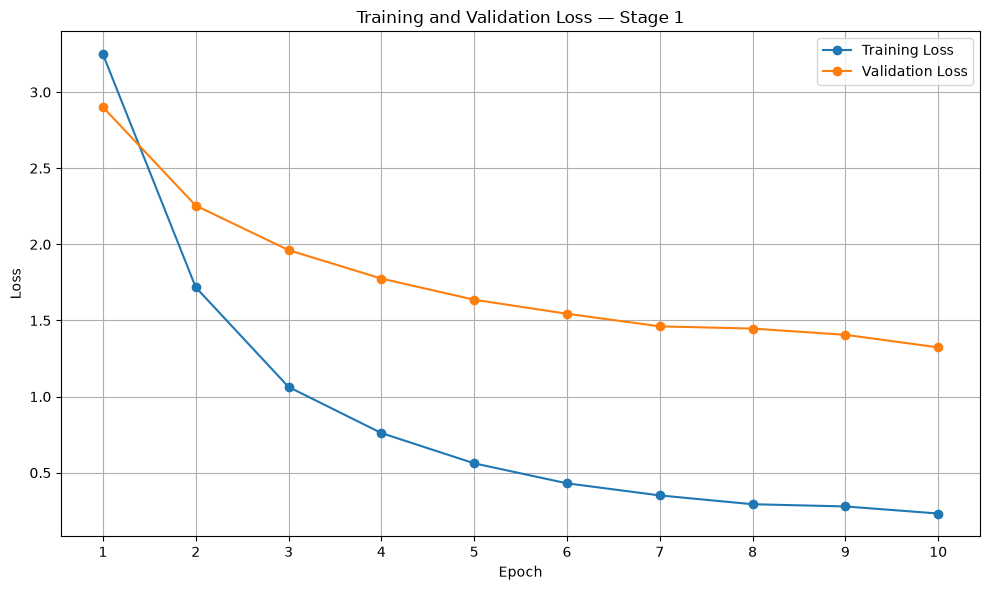

In [72]:
# ============================================================
# STEP 6 — CELL 1
# TRAINING AND VALIDATION LOSS CURVE
# ============================================================

import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss — Stage 1")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

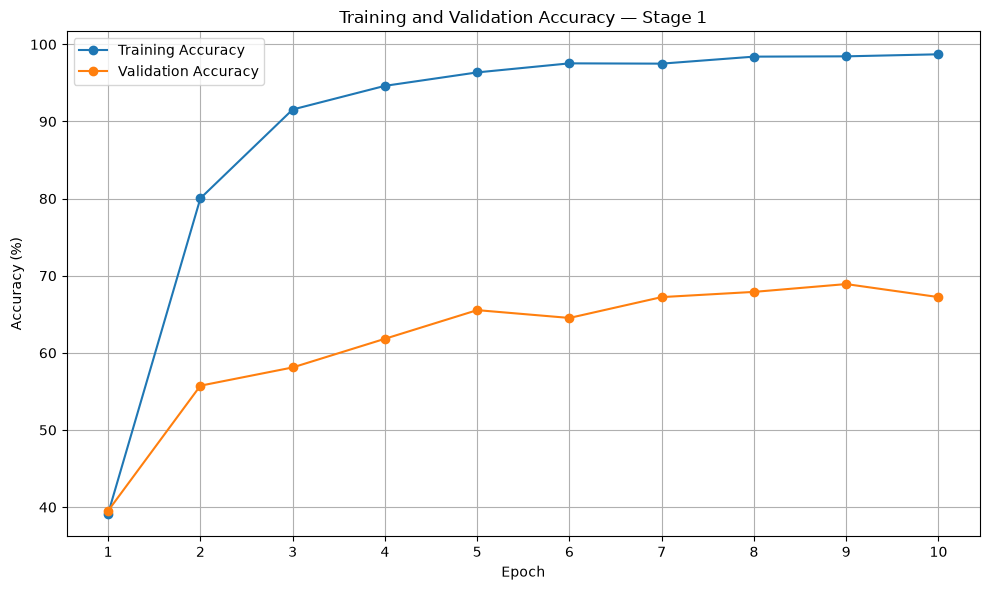

In [73]:
# ============================================================
# STEP 6 — CELL 2
# TRAINING AND VALIDATION ACCURACY CURVE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    [accuracy * 100 for accuracy in history["train_accuracy"]],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    [accuracy * 100 for accuracy in history["val_accuracy"]],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy — Stage 1")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [74]:
# ============================================================
# STEP 6 — CELL 3
# SAVE STAGE 1 BEST MODEL
# ============================================================

stage1_checkpoint_path = (
    CHECKPOINT_DIR / "resnet50_stage1_best.pth"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "best_val_loss": best_val_loss,
        "best_val_accuracy": max(history["val_accuracy"]),
        "num_classes": NUM_CLASSES,
        "image_size": IMAGE_SIZE,
    },
    stage1_checkpoint_path
)

print("STAGE 1 MODEL CHECKPOINT SAVED")
print("=" * 60)
print("Checkpoint:", stage1_checkpoint_path)
print("Best validation loss:",
      f"{best_val_loss:.6f}")
print("Best validation accuracy:",
      f"{max(history['val_accuracy']):.6f}")
print("File exists:", stage1_checkpoint_path.exists())

STAGE 1 MODEL CHECKPOINT SAVED
Checkpoint: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\results\checkpoints\resnet50_stage1_best.pth
Best validation loss: 1.323240
Best validation accuracy: 0.689189
File exists: True


Step 7 — Cell 1: Inspect ResNet-50 architecture

In [75]:
# ============================================================
# STEP 7 — CELL 1
# INSPECT RESNET-50 LAYERS
# ============================================================

print("RESNET-50 ARCHITECTURE")
print("=" * 70)

for name, module in model.named_children():
    print(f"{name:15s} : {module.__class__.__name__}")

print("\nResNet-50 feature blocks:")
print("-" * 70)

for name, module in model.named_children():
    if name.startswith("layer"):
        print(f"{name:15s} : {module}")

RESNET-50 ARCHITECTURE
conv1           : Conv2d
bn1             : BatchNorm2d
relu            : ReLU
maxpool         : MaxPool2d
layer1          : Sequential
layer2          : Sequential
layer3          : Sequential
layer4          : Sequential
avgpool         : AdaptiveAvgPool2d
fc              : Linear

ResNet-50 feature blocks:
----------------------------------------------------------------------
layer1          : Sequential(
  (0): Bottleneck(
    (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True

In [76]:
# ============================================================
# STEP 7 — CELL 2
# STAGE 2 PARTIAL FINE-TUNING CONFIGURATION
# ============================================================

# Freeze the entire model first
for parameter in model.parameters():
    parameter.requires_grad = False


# ------------------------------------------------------------
# Unfreeze the final ResNet feature block
# ------------------------------------------------------------

for parameter in model.layer4.parameters():
    parameter.requires_grad = True


# ------------------------------------------------------------
# Keep the 81-class classifier trainable
# ------------------------------------------------------------

for parameter in model.fc.parameters():
    parameter.requires_grad = True


# ------------------------------------------------------------
# Count parameters
# ------------------------------------------------------------

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

frozen_parameters = total_parameters - trainable_parameters


print("STAGE 2 PARTIAL FINE-TUNING CONFIGURED")
print("=" * 60)

print(f"Total parameters     : {total_parameters:,}")
print(f"Trainable parameters : {trainable_parameters:,}")
print(f"Frozen parameters    : {frozen_parameters:,}")

print("\nTrainable layers:")

for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        print(name)

STAGE 2 PARTIAL FINE-TUNING CONFIGURED
Total parameters     : 23,674,001
Trainable parameters : 15,130,705
Frozen parameters    : 8,543,296

Trainable layers:
layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.conv3.weight
layer4.0.bn3.weight
layer4.0.bn3.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
layer4.1.conv3.weight
layer4.1.bn3.weight
layer4.1.bn3.bias
layer4.2.conv1.weight
layer4.2.bn1.weight
layer4.2.bn1.bias
layer4.2.conv2.weight
layer4.2.bn2.weight
layer4.2.bn2.bias
layer4.2.conv3.weight
layer4.2.bn3.weight
layer4.2.bn3.bias
fc.weight
fc.bias


In [77]:
# ============================================================
# STEP 7 — CELL 3
# STAGE 2 PARAMETER FREEZING SANITY CHECK
# ============================================================

def count_trainable(module):
    return sum(
        parameter.numel()
        for parameter in module.parameters()
        if parameter.requires_grad
    )


def count_frozen(module):
    return sum(
        parameter.numel()
        for parameter in module.parameters()
        if not parameter.requires_grad
    )


print("STAGE 2 FREEZING SANITY CHECK")
print("=" * 60)

blocks = [
    ("conv1", model.conv1),
    ("bn1", model.bn1),
    ("layer1", model.layer1),
    ("layer2", model.layer2),
    ("layer3", model.layer3),
    ("layer4", model.layer4),
    ("fc", model.fc),
]

for name, module in blocks:
    trainable = count_trainable(module)
    frozen = count_frozen(module)

    print(
        f"{name:8s} | "
        f"Trainable: {trainable:>10,} | "
        f"Frozen: {frozen:>10,}"
    )


# ------------------------------------------------------------
# Explicit checks
# ------------------------------------------------------------

early_blocks_frozen = all(
    not parameter.requires_grad
    for parameter in list(model.conv1.parameters())
    + list(model.bn1.parameters())
    + list(model.layer1.parameters())
    + list(model.layer2.parameters())
    + list(model.layer3.parameters())
)

late_blocks_trainable = all(
    parameter.requires_grad
    for parameter in list(model.layer4.parameters())
    + list(model.fc.parameters())
)


print("\nVerification:")
print("Early layers completely frozen :", early_blocks_frozen)
print("layer4 + FC completely trainable:", late_blocks_trainable)

assert early_blocks_frozen, "ERROR: An early layer is unexpectedly trainable."
assert late_blocks_trainable, "ERROR: layer4 or FC is unexpectedly frozen."

print("\nSTAGE 2 FREEZING CHECK PASSED")

STAGE 2 FREEZING SANITY CHECK
conv1    | Trainable:          0 | Frozen:      9,408
bn1      | Trainable:          0 | Frozen:        128
layer1   | Trainable:          0 | Frozen:    215,808
layer2   | Trainable:          0 | Frozen:  1,219,584
layer3   | Trainable:          0 | Frozen:  7,098,368
layer4   | Trainable: 14,964,736 | Frozen:          0
fc       | Trainable:    165,969 | Frozen:          0

Verification:
Early layers completely frozen : True
layer4 + FC completely trainable: True

STAGE 2 FREEZING CHECK PASSED


In [78]:
# ============================================================
# STEP 7 — CELL 4
# STAGE 2 OPTIMIZER CONFIGURATION
# ============================================================

STAGE2_LAYER4_LR = 1e-5
STAGE2_FC_LR = 1e-4
STAGE2_WEIGHT_DECAY = 1e-4

optimizer_stage2 = torch.optim.AdamW(
    [
        {
            "params": model.layer4.parameters(),
            "lr": STAGE2_LAYER4_LR
        },
        {
            "params": model.fc.parameters(),
            "lr": STAGE2_FC_LR
        }
    ],
    weight_decay=STAGE2_WEIGHT_DECAY
)

print("STAGE 2 OPTIMIZER CONFIGURED")
print("=" * 60)

print("Optimizer       : AdamW")
print("layer4 LR       :", STAGE2_LAYER4_LR)
print("FC LR           :", STAGE2_FC_LR)
print("Weight decay    :", STAGE2_WEIGHT_DECAY)

print("\nOptimizer parameter groups:")

for i, group in enumerate(optimizer_stage2.param_groups):
    parameter_count = sum(
        parameter.numel()
        for parameter in group["params"]
    )

    print(
        f"Group {i + 1} | "
        f"Learning rate: {group['lr']} | "
        f"Parameters: {parameter_count:,}"
    )

total_optimizer_parameters = sum(
    sum(parameter.numel() for parameter in group["params"])
    for group in optimizer_stage2.param_groups
)

print("\nTotal optimizer parameters:",
      f"{total_optimizer_parameters:,}")

assert total_optimizer_parameters == trainable_parameters

print("\nSTAGE 2 OPTIMIZER CHECK PASSED")

STAGE 2 OPTIMIZER CONFIGURED
Optimizer       : AdamW
layer4 LR       : 1e-05
FC LR           : 0.0001
Weight decay    : 0.0001

Optimizer parameter groups:
Group 1 | Learning rate: 1e-05 | Parameters: 14,964,736
Group 2 | Learning rate: 0.0001 | Parameters: 165,969

Total optimizer parameters: 15,130,705

STAGE 2 OPTIMIZER CHECK PASSED


In [79]:
# ============================================================
# STEP 7 — CELL 5
# STAGE 2 LEARNING-RATE SCHEDULER
# ============================================================

scheduler_stage2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage2,
    mode="min",
    factor=0.1,
    patience=2
)

print("STAGE 2 SCHEDULER CONFIGURED")
print("=" * 60)

print("Scheduler        :", scheduler_stage2.__class__.__name__)
print("Mode             : min")
print("Reduction factor : 0.1")
print("Patience         : 2")

print("\nInitial learning rates:")

for i, group in enumerate(optimizer_stage2.param_groups):
    print(
        f"Group {i + 1}: {group['lr']}"
    )

print("\nSTAGE 2 SCHEDULER CHECK PASSED")

STAGE 2 SCHEDULER CONFIGURED
Scheduler        : ReduceLROnPlateau
Mode             : min
Reduction factor : 0.1
Patience         : 2

Initial learning rates:
Group 1: 1e-05
Group 2: 0.0001

STAGE 2 SCHEDULER CHECK PASSED


In [80]:
# ============================================================
# STEP 7 — CELL 6
# STAGE 2 GRADIENT SANITY CHECK
# ============================================================

model.train()

# Get one training batch
images, fine_labels, _ = next(iter(train_loader))

images = images.to(DEVICE)
fine_labels = fine_labels.to(DEVICE)

# Clear existing gradients
optimizer_stage2.zero_grad()

# Forward pass
outputs = model(images)

# Calculate loss
loss = criterion(outputs, fine_labels)

# Backward pass
loss.backward()

# ------------------------------------------------------------
# Check gradients
# ------------------------------------------------------------

layer4_gradient_exists = False
layer4_gradient_norm = 0.0

for parameter in model.layer4.parameters():
    if parameter.grad is not None:
        layer4_gradient_exists = True
        layer4_gradient_norm += parameter.grad.norm().item()

fc_weight_gradient = model.fc.weight.grad
fc_bias_gradient = model.fc.bias.grad

# ------------------------------------------------------------
# Check frozen layers
# ------------------------------------------------------------

frozen_gradient_exists = False

for module in [
    model.conv1,
    model.bn1,
    model.layer1,
    model.layer2,
    model.layer3
]:
    for parameter in module.parameters():
        if parameter.grad is not None:
            frozen_gradient_exists = True
            break

print("STAGE 2 GRADIENT SANITY CHECK")
print("=" * 60)

print("Input shape              :", tuple(images.shape))
print("Output shape             :", tuple(outputs.shape))
print("Loss                     :", f"{loss.item():.6f}")

print("\nTrainable layer gradients:")
print("layer4 gradient exists   :", layer4_gradient_exists)
print("layer4 gradient norm     :", f"{layer4_gradient_norm:.6f}")
print("FC weight gradient exists:", fc_weight_gradient is not None)
print("FC bias gradient exists  :", fc_bias_gradient is not None)

print("\nFrozen layer check:")
print(
    "Frozen layers have gradients:",
    frozen_gradient_exists
)

gradient_check = (
    layer4_gradient_exists
    and fc_weight_gradient is not None
    and fc_bias_gradient is not None
    and torch.isfinite(
        torch.tensor(layer4_gradient_norm)
    )
    and layer4_gradient_norm > 0
    and torch.isfinite(fc_weight_gradient).all()
    and torch.isfinite(fc_bias_gradient).all()
    and not frozen_gradient_exists
)

if gradient_check:
    print("\nSTAGE 2 GRADIENT CHECK PASSED")
else:
    print("\nSTAGE 2 GRADIENT CHECK FAILED")

# Clear gradients after the test
optimizer_stage2.zero_grad()

STAGE 2 GRADIENT SANITY CHECK
Input shape              : (32, 3, 224, 224)
Output shape             : (32, 81)
Loss                     : 0.167242

Trainable layer gradients:
layer4 gradient exists   : True
layer4 gradient norm     : 5.476660
FC weight gradient exists: True
FC bias gradient exists  : True

Frozen layer check:
Frozen layers have gradients: False

STAGE 2 GRADIENT CHECK PASSED


In [81]:
# ============================================================
# STEP 8 — CELL 1
# RECREATE VALIDATION FUNCTION
# ============================================================

def validate(model, data_loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, fine_labels, _ in data_loader:

            images = images.to(device)
            fine_labels = fine_labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, fine_labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == fine_labels
            ).sum().item()

            total += fine_labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("Validation function recreated successfully")

Validation function recreated successfully


In [82]:
# ============================================================
# STEP 8 — CELL 2
# RESTORE STAGE 1 CHECKPOINT FOR CLEAN STAGE 2 RUN
# ============================================================

checkpoint = torch.load(
    stage1_checkpoint_path,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)

print("STAGE 1 CHECKPOINT RESTORED")
print("=" * 60)

print("Checkpoint:", stage1_checkpoint_path)
print(
    "Stage 1 best validation loss:",
    f"{checkpoint['best_val_loss']:.6f}"
)
print(
    "Stage 1 best validation accuracy:",
    f"{checkpoint['best_val_accuracy']:.6f}"
)
print("Model device:", DEVICE)

STAGE 1 CHECKPOINT RESTORED
Checkpoint: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\results\checkpoints\resnet50_stage1_best.pth
Stage 1 best validation loss: 1.323240
Stage 1 best validation accuracy: 0.689189
Model device: cpu


In [83]:
# ============================================================
# STEP 8 — CELL 3
# RESET STAGE 2 OPTIMIZER AND SCHEDULER
# ============================================================

# ------------------------------------------------------------
# Make sure Stage 2 freezing is active
# ------------------------------------------------------------

for parameter in model.parameters():
    parameter.requires_grad = False

for parameter in model.layer4.parameters():
    parameter.requires_grad = True

for parameter in model.fc.parameters():
    parameter.requires_grad = True


# ------------------------------------------------------------
# Create a completely fresh Stage 2 optimizer
# ------------------------------------------------------------

STAGE2_LAYER4_LR = 1e-5
STAGE2_FC_LR = 1e-4
STAGE2_WEIGHT_DECAY = 1e-4

optimizer_stage2 = torch.optim.AdamW(
    [
        {
            "params": model.layer4.parameters(),
            "lr": STAGE2_LAYER4_LR
        },
        {
            "params": model.fc.parameters(),
            "lr": STAGE2_FC_LR
        }
    ],
    weight_decay=STAGE2_WEIGHT_DECAY
)


# ------------------------------------------------------------
# Create a completely fresh scheduler
# ------------------------------------------------------------

scheduler_stage2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage2,
    mode="min",
    factor=0.1,
    patience=2
)


# ------------------------------------------------------------
# Verify optimizer
# ------------------------------------------------------------

optimizer_parameter_count = sum(
    parameter.numel()
    for group in optimizer_stage2.param_groups
    for parameter in group["params"]
)

print("STAGE 2 OPTIMIZER/SCHEDULER RESET")
print("=" * 60)

print("Optimizer:", optimizer_stage2.__class__.__name__)
print("Scheduler:", scheduler_stage2.__class__.__name__)

print("\nLearning rates:")
print("Layer4:", STAGE2_LAYER4_LR)
print("FC    :", STAGE2_FC_LR)

print("\nOptimizer parameters:",
      f"{optimizer_parameter_count:,}")

print("\nStage 2 optimizer state reset successfully")
print("Stage 2 scheduler state reset successfully")

assert optimizer_parameter_count == 15_130_705

print("\nSTAGE 2 OPTIMIZER RESET CHECK PASSED")

STAGE 2 OPTIMIZER/SCHEDULER RESET
Optimizer: AdamW
Scheduler: ReduceLROnPlateau

Learning rates:
Layer4: 1e-05
FC    : 0.0001

Optimizer parameters: 15,130,705

Stage 2 optimizer state reset successfully
Stage 2 scheduler state reset successfully

STAGE 2 OPTIMIZER RESET CHECK PASSED


In [84]:
# ============================================================
# STEP 8 — CELL 4
# CLEAN STAGE 2 FINE-TUNING
# ============================================================

STAGE2_EPOCHS = 10

stage2_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate_layer4": [],
    "learning_rate_fc": []
}

best_stage2_val_loss = float("inf")
best_stage2_val_accuracy = 0.0
best_stage2_state = None

print("STAGE 2 FINE-TUNING")
print("=" * 60)
print("Epochs              :", STAGE2_EPOCHS)
print("Trainable blocks    : layer4 + fc")
print("Device              :", DEVICE)
print("Layer4 learning rate:", STAGE2_LAYER4_LR)
print("FC learning rate    :", STAGE2_FC_LR)
print("Starting training...\n")


for epoch in range(STAGE2_EPOCHS):

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer_stage2,
        DEVICE
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler_stage2.step(val_loss)

    current_layer4_lr = optimizer_stage2.param_groups[0]["lr"]
    current_fc_lr = optimizer_stage2.param_groups[1]["lr"]

    # --------------------------------------------------------
    # Save history
    # --------------------------------------------------------

    stage2_history["train_loss"].append(train_loss)
    stage2_history["train_accuracy"].append(train_accuracy)
    stage2_history["val_loss"].append(val_loss)
    stage2_history["val_accuracy"].append(val_accuracy)
    stage2_history["learning_rate_layer4"].append(
        current_layer4_lr
    )
    stage2_history["learning_rate_fc"].append(
        current_fc_lr
    )

    # --------------------------------------------------------
    # Save best model based on validation loss
    # --------------------------------------------------------

    if val_loss < best_stage2_val_loss:

        best_stage2_val_loss = val_loss
        best_stage2_val_accuracy = val_accuracy

        best_stage2_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

        best_marker = "  <- BEST"

    else:
        best_marker = ""

    print(
        f"Epoch [{epoch + 1:02d}/{STAGE2_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Layer4 LR: {current_layer4_lr:.6f} | "
        f"FC LR: {current_fc_lr:.6f}"
        f"{best_marker}"
    )


# ------------------------------------------------------------
# Restore best Stage 2 model
# ------------------------------------------------------------

if best_stage2_state is not None:

    model.load_state_dict(best_stage2_state)

    print("\n" + "=" * 60)
    print("STAGE 2 FINE-TUNING COMPLETED")
    print("=" * 60)

    print(
        "Best validation loss:",
        f"{best_stage2_val_loss:.6f}"
    )

    print(
        "Best validation accuracy:",
        f"{best_stage2_val_accuracy:.6f}"
    )

    print("Best Stage 2 model restored successfully")

STAGE 2 FINE-TUNING
Epochs              : 10
Trainable blocks    : layer4 + fc
Device              : cpu
Layer4 learning rate: 1e-05
FC learning rate    : 0.0001
Starting training...

Epoch [01/10] | Train Loss: 0.1571 | Train Acc: 0.9909 | Val Loss: 1.1841 | Val Acc: 0.6791 | Layer4 LR: 0.000010 | FC LR: 0.000100  <- BEST
Epoch [02/10] | Train Loss: 0.1131 | Train Acc: 0.9890 | Val Loss: 1.1155 | Val Acc: 0.6892 | Layer4 LR: 0.000010 | FC LR: 0.000100  <- BEST
Epoch [03/10] | Train Loss: 0.0874 | Train Acc: 0.9920 | Val Loss: 1.0962 | Val Acc: 0.7196 | Layer4 LR: 0.000010 | FC LR: 0.000100  <- BEST
Epoch [04/10] | Train Loss: 0.0703 | Train Acc: 0.9943 | Val Loss: 1.0233 | Val Acc: 0.7230 | Layer4 LR: 0.000010 | FC LR: 0.000100  <- BEST
Epoch [05/10] | Train Loss: 0.0628 | Train Acc: 0.9924 | Val Loss: 1.0316 | Val Acc: 0.7264 | Layer4 LR: 0.000010 | FC LR: 0.000100
Epoch [06/10] | Train Loss: 0.0563 | Train Acc: 0.9943 | Val Loss: 1.0034 | Val Acc: 0.7264 | Layer4 LR: 0.000010 | FC L

In [85]:
# ============================================================
# STEP 9 — CELL 1
# SAVE STAGE 2 TRAINING HISTORY
# ============================================================

stage2_history_path = (
    RESULTS_DIR / "training_history_stage2.json"
)

with open(stage2_history_path, "w") as f:
    json.dump(stage2_history, f, indent=4)

print("STAGE 2 TRAINING HISTORY SAVED")
print("=" * 60)

print("History file:", stage2_history_path)
print("Epochs recorded:", len(stage2_history["train_loss"]))

print(
    "Best validation loss:",
    f"{best_stage2_val_loss:.6f}"
)

print(
    "Best validation accuracy:",
    f"{best_stage2_val_accuracy:.6f}"
)

print("File exists:", stage2_history_path.exists())

STAGE 2 TRAINING HISTORY SAVED
History file: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\results\training_history_stage2.json
Epochs recorded: 10
Best validation loss: 0.933781
Best validation accuracy: 0.722973
File exists: True


Step 10 — Final Test Evaluation

In [86]:
# ============================================================
# STEP 10 — CELL 1
# FINAL TEST SET EVALUATION
# ============================================================

model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

all_test_predictions = []
all_test_labels = []

with torch.no_grad():

    for images, fine_labels, _ in test_loader:

        images = images.to(DEVICE)
        fine_labels = fine_labels.to(DEVICE)

        outputs = model(images)

        loss = criterion(outputs, fine_labels)

        test_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        test_correct += (
            predictions == fine_labels
        ).sum().item()

        test_total += fine_labels.size(0)

        all_test_predictions.extend(
            predictions.cpu().numpy()
        )

        all_test_labels.extend(
            fine_labels.cpu().numpy()
        )


# ------------------------------------------------------------
# Calculate final metrics
# ------------------------------------------------------------

test_loss = test_loss / test_total
test_accuracy = test_correct / test_total

print("FINAL TEST SET EVALUATION")
print("=" * 60)

print("Test samples       :", test_total)
print("Correct predictions:", test_correct)
print("Incorrect predictions:", test_total - test_correct)

print("\nTest loss           :", f"{test_loss:.6f}")
print(
    "Test accuracy       :",
    f"{test_accuracy:.6f}"
)
print(
    "Test accuracy (%)   :",
    f"{test_accuracy * 100:.2f}%"
)

print("\nPredictions stored  :", len(all_test_predictions))
print("Labels stored       :", len(all_test_labels))

assert test_total == len(test_loader.dataset)
assert len(all_test_predictions) == test_total
assert len(all_test_labels) == test_total

print("\nFINAL TEST EVALUATION PASSED")

FINAL TEST SET EVALUATION
Test samples       : 2485
Correct predictions: 1832
Incorrect predictions: 653

Test loss           : 0.879393
Test accuracy       : 0.737223
Test accuracy (%)   : 73.72%

Predictions stored  : 2485
Labels stored       : 2485

FINAL TEST EVALUATION PASSED


In [87]:
# ============================================================
# STEP 10 — CELL 2A
# RECREATE FINE-GRAINED CLASS NAMES
# ============================================================

classes_df = pd.read_csv(CLASSES_CSV)

class_names = (
    classes_df
    .sort_values("Class ID (int)")
    ["Class Name (str)"]
    .tolist()
)

print("Fine-grained class names recreated successfully")
print("=" * 60)

print("Number of classes:", len(class_names))

print("\nFirst 10 classes:")
for class_id, class_name in enumerate(class_names[:10]):
    print(f"{class_id:2d} : {class_name}")

assert len(class_names) == NUM_CLASSES
assert len(class_names) == 81

print("\nCLASS NAME CHECK PASSED")

Fine-grained class names recreated successfully
Number of classes: 81

First 10 classes:
 0 : Golden-Delicious
 1 : Granny-Smith
 2 : Pink-Lady
 3 : Red-Delicious
 4 : Royal-Gala
 5 : Avocado
 6 : Banana
 7 : Kiwi
 8 : Lemon
 9 : Lime

CLASS NAME CHECK PASSED


In [88]:
# ============================================================
# STEP 10 — CELL 2B
# FINAL CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report
import pandas as pd

classification_report_dict = classification_report(
    all_test_labels,
    all_test_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(
    classification_report_dict
).transpose()

print("FINAL CLASSIFICATION REPORT")
print("=" * 90)

display(classification_report_df.round(4))

print("\nOverall test accuracy:",
      f"{test_accuracy * 100:.2f}%")

print("\nClassification report generated successfully")

assert len(classification_report_df) >= 81

print("CLASSIFICATION REPORT CHECK PASSED")

FINAL CLASSIFICATION REPORT


,precision,recall,f1-score,support
Golden-Delicious,0.3818,0.4667,0.4200,45.0000
Granny-Smith,0.4787,0.7759,0.5921,58.0000
Pink-Lady,0.8485,0.9492,0.8960,59.0000
Red-Delicious,0.8596,0.9800,0.9159,50.0000
Royal-Gala,0.7500,0.7500,0.7500,64.0000
...,...,...,...,...
Vine-Tomato,0.9730,0.8372,0.9000,43.0000
Zucchini,0.7000,0.9655,0.8116,29.0000
accuracy,0.7372,0.7372,0.7372,0.7372
macro avg,0.7384,0.7195,0.7140,2485.0000



Overall test accuracy: 73.72%

Classification report generated successfully
CLASSIFICATION REPORT CHECK PASSED


FINAL CONFUSION MATRIX
Matrix shape: (81, 81)
Total samples: 2485

CONFUSION MATRIX CHECK PASSED


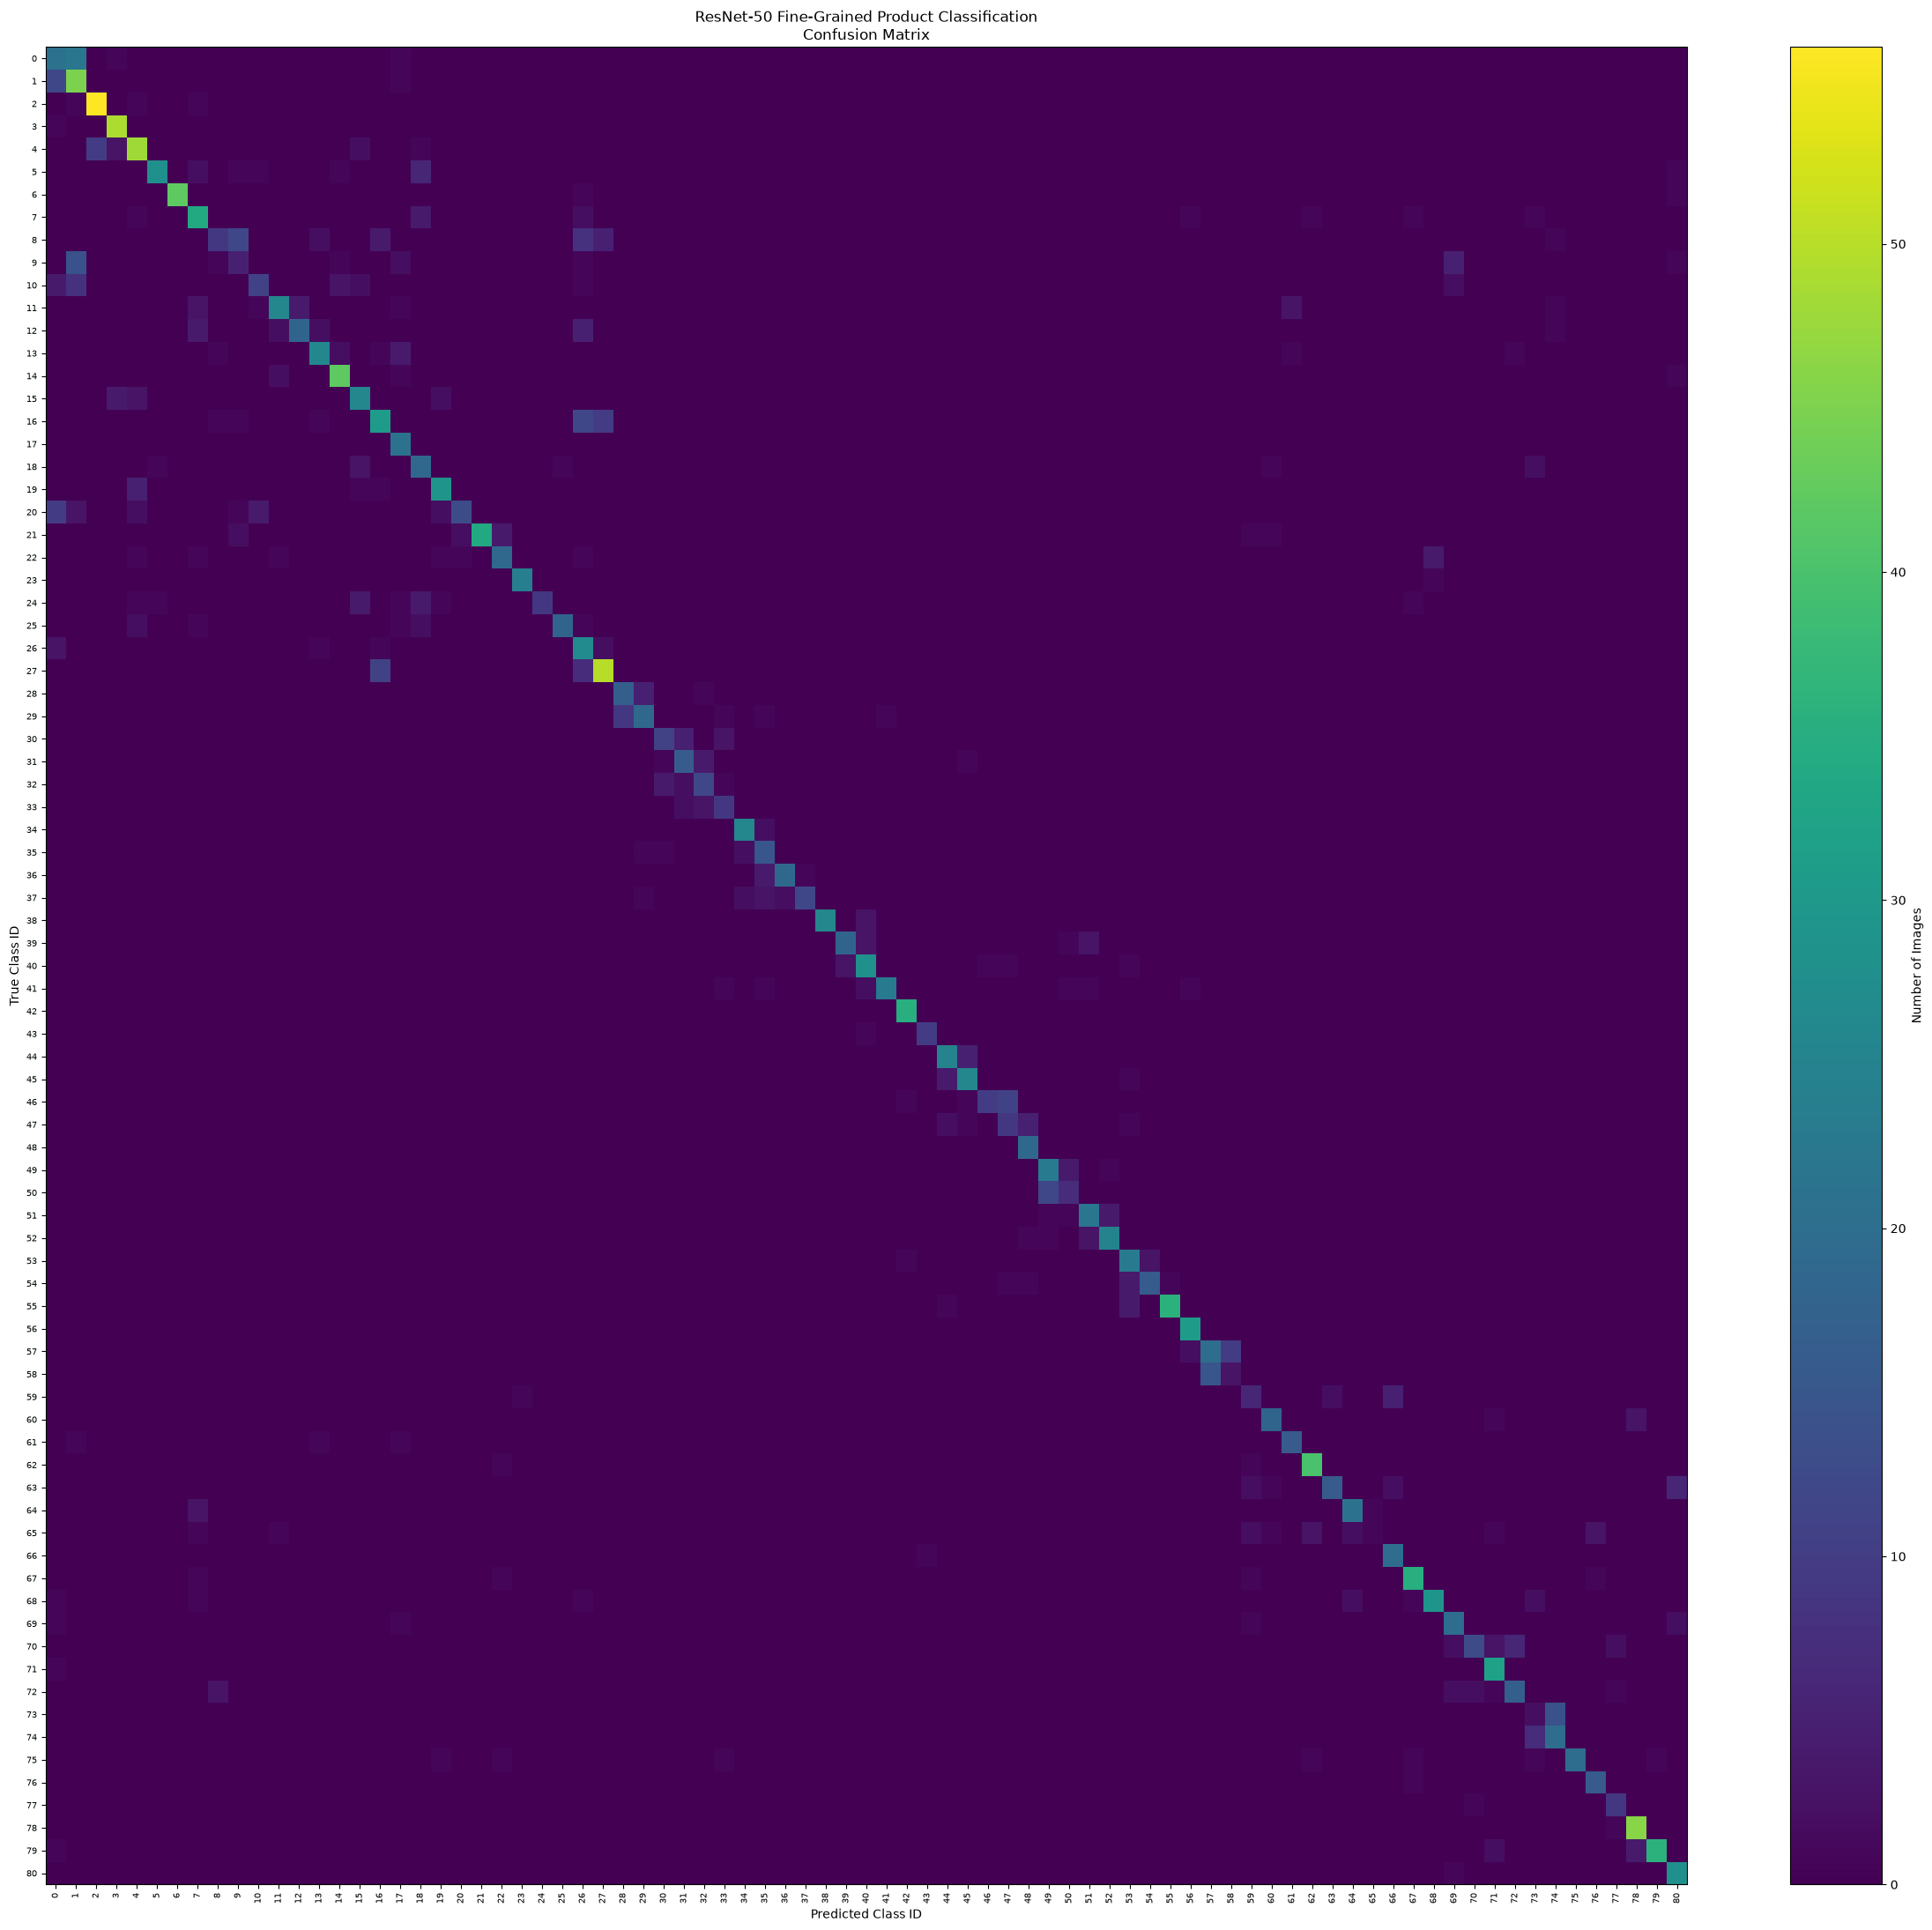

In [89]:
# ============================================================
# STEP 10 — CELL 3
# FINAL CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Generate confusion matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    all_test_labels,
    all_test_predictions,
    labels=list(range(NUM_CLASSES))
)

print("FINAL CONFUSION MATRIX")
print("=" * 70)

print("Matrix shape:", cm.shape)
print("Total samples:", cm.sum())

assert cm.shape == (NUM_CLASSES, NUM_CLASSES)
assert cm.sum() == len(all_test_labels)

print("\nCONFUSION MATRIX CHECK PASSED")


# ------------------------------------------------------------
# Plot confusion matrix
# ------------------------------------------------------------

plt.figure(figsize=(24, 22))

plt.imshow(
    cm,
    interpolation="nearest",
    aspect="auto"
)

plt.title(
    "ResNet-50 Fine-Grained Product Classification\n"
    "Confusion Matrix"
)

plt.xlabel("Predicted Class ID")
plt.ylabel("True Class ID")

plt.xticks(
    ticks=np.arange(NUM_CLASSES),
    labels=np.arange(NUM_CLASSES),
    rotation=90,
    fontsize=7
)

plt.yticks(
    ticks=np.arange(NUM_CLASSES),
    labels=np.arange(NUM_CLASSES),
    fontsize=7
)

plt.colorbar(
    label="Number of Images"
)

plt.tight_layout()

plt.show()

In [90]:
# ============================================================
# STEP 10 — CELL 4
# TOP CONFUSED PRODUCT PAIRS
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Remove correct predictions from the confusion matrix
# ------------------------------------------------------------

cm_off_diagonal = cm.copy()

# Set diagonal to zero
np.fill_diagonal(cm_off_diagonal, 0)

# ------------------------------------------------------------
# Find the strongest confusion pairs
# ------------------------------------------------------------

confusion_pairs = []

for true_class in range(NUM_CLASSES):
    for predicted_class in range(NUM_CLASSES):

        count = cm_off_diagonal[true_class, predicted_class]

        if count > 0:

            confusion_pairs.append({
                "True Class ID": true_class,
                "True Class": class_names[true_class],
                "Predicted Class ID": predicted_class,
                "Predicted Class": class_names[predicted_class],
                "Misclassified Images": int(count)
            })


# ------------------------------------------------------------
# Sort by number of errors
# ------------------------------------------------------------

confusion_pairs_df = pd.DataFrame(confusion_pairs)

confusion_pairs_df = confusion_pairs_df.sort_values(
    by="Misclassified Images",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# Display top 20
# ------------------------------------------------------------

print("TOP 20 MOST FREQUENT CONFUSIONS")
print("=" * 100)

display(
    confusion_pairs_df.head(20)
)

print("\nTotal off-diagonal errors:",
      int(cm_off_diagonal.sum()))

print("Total test errors:",
      test_total - test_correct)

assert int(cm_off_diagonal.sum()) == test_total - test_correct

print("\nCONFUSION ANALYSIS CHECK PASSED")

TOP 20 MOST FREQUENT CONFUSIONS


,True Class ID,True Class,Predicted Class ID,Predicted Class,Misclassified Images
0,0,Golden-Delicious,1,Granny-Smith,22
1,58,Yoggi-Vanilla-Yoghurt,57,Yoggi-Strawberry-Yoghurt,15
2,73,Floury-Potato,74,Solid-Potato,14
3,9,Lime,1,Granny-Smith,14
4,16,Orange,26,Red-Grapefruit,12
5,50,Alpro-Vanilla-Soyghurt,49,Alpro-Blueberry-Soyghurt,12
6,8,Lemon,9,Lime,12
7,1,Granny-Smith,0,Golden-Delicious,12
8,46,Arla-Ecological-Sour-Cream,47,Arla-Sour-Cream,11
9,27,Satsumas,16,Orange,11



Total off-diagonal errors: 653
Total test errors: 653

CONFUSION ANALYSIS CHECK PASSED


In [91]:
# ============================================================
# STEP 10 — CELL 5
# CLASS-WISE PERFORMANCE ANALYSIS
# ============================================================

# ------------------------------------------------------------
# Extract only the 81 product classes
# ------------------------------------------------------------

class_metrics_df = classification_report_df.iloc[:NUM_CLASSES].copy()

class_metrics_df = class_metrics_df[
    ["precision", "recall", "f1-score", "support"]
].copy()

class_metrics_df["Class ID"] = range(NUM_CLASSES)
class_metrics_df["Class"] = class_names

class_metrics_df = class_metrics_df[
    [
        "Class ID",
        "Class",
        "precision",
        "recall",
        "f1-score",
        "support"
    ]
]


# ------------------------------------------------------------
# Sort by F1-score
# ------------------------------------------------------------

class_metrics_sorted = class_metrics_df.sort_values(
    by="f1-score",
    ascending=True
).reset_index(drop=True)


# ------------------------------------------------------------
# Display lowest-performing classes
# ------------------------------------------------------------

print("LOWEST-PERFORMING PRODUCT CLASSES")
print("=" * 100)

display(
    class_metrics_sorted.head(15).round(4)
)


# ------------------------------------------------------------
# Display highest-performing classes
# ------------------------------------------------------------

print("\nHIGHEST-PERFORMING PRODUCT CLASSES")
print("=" * 100)

display(
    class_metrics_sorted.tail(15)
    .sort_values("f1-score", ascending=False)
    .round(4)
)


# ------------------------------------------------------------
# Summary statistics
# ------------------------------------------------------------

print("\nCLASS-WISE PERFORMANCE SUMMARY")
print("=" * 70)

print(
    "Mean precision :",
    f"{class_metrics_df['precision'].mean():.4f}"
)

print(
    "Mean recall    :",
    f"{class_metrics_df['recall'].mean():.4f}"
)

print(
    "Mean F1-score  :",
    f"{class_metrics_df['f1-score'].mean():.4f}"
)

print(
    "Weighted F1    :",
    f"{classification_report_df.loc['weighted avg', 'f1-score']:.4f}"
)

print(
    "Macro F1       :",
    f"{classification_report_df.loc['macro avg', 'f1-score']:.4f}"
)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

assert len(class_metrics_df) == NUM_CLASSES
assert class_metrics_df["support"].sum() == test_total

print("\nCLASS-WISE ANALYSIS CHECK PASSED")

LOWEST-PERFORMING PRODUCT CLASSES


,Class ID,Class,precision,recall,f1-score,support
0,65,Ginger,0.5000,0.0667,0.1176,15.0
1,73,Floury-Potato,0.1333,0.1250,0.1290,16.0
2,9,Lime,0.2273,0.1667,0.1923,30.0
3,58,Yoggi-Vanilla-Yoghurt,0.2308,0.1667,0.1935,18.0
4,8,Lemon,0.6000,0.2195,0.3214,41.0
5,0,Golden-Delicious,0.3818,0.4667,0.4200,45.0
6,50,Alpro-Vanilla-Soyghurt,0.5000,0.3684,0.4242,19.0
7,59,Asparagus,0.4286,0.4286,0.4286,14.0
8,47,Arla-Sour-Cream,0.4091,0.5000,0.4500,18.0
9,10,Mango,0.6471,0.3548,0.4583,31.0



HIGHEST-PERFORMING PRODUCT CLASSES


,Class ID,Class,precision,recall,f1-score,support
80,6,Banana,1.0000,0.9545,0.9767,44.0
79,42,Garant-Ecological-Medium-Fat-Milk,0.9459,1.0000,0.9722,35.0
78,23,Pineapple,0.9600,0.9600,0.9600,25.0
77,38,Arla-Ecological-Medium-Fat-Milk,1.0000,0.8966,0.9455,29.0
76,56,Valio-Vanilla-Yoghurt,0.8857,1.0000,0.9394,31.0
75,55,Arla-Natural-Yoghurt,0.9730,0.8780,0.9231,41.0
74,78,Regular-Tomato,0.8679,0.9787,0.9200,47.0
73,62,Carrots,0.8889,0.9524,0.9195,42.0
72,3,Red-Delicious,0.8596,0.9800,0.9159,50.0
71,43,Garant-Ecological-Standard-Milk,0.9091,0.9091,0.9091,11.0



CLASS-WISE PERFORMANCE SUMMARY
Mean precision : 0.7384
Mean recall    : 0.7195
Mean F1-score  : 0.7140
Weighted F1    : 0.7319
Macro F1       : 0.7140

CLASS-WISE ANALYSIS CHECK PASSED


In [106]:
# ============================================================
# STEP 10 — CELL 6
# SAVE CURRENT STAGE 2 BASELINE RESULTS
# ============================================================

import json
from pathlib import Path

# ------------------------------------------------------------
# Get Stage 2 best result based on validation loss
# ------------------------------------------------------------
best_loss_index = min(
    range(len(stage2_history["val_loss"])),
    key=lambda i: stage2_history["val_loss"][i]
)

current_stage2_best_val_loss = stage2_history["val_loss"][best_loss_index]
current_stage2_val_accuracy_at_best_loss = (
    stage2_history["val_accuracy"][best_loss_index]
)

current_stage2_best_epoch = best_loss_index + 1

# ------------------------------------------------------------
# Get best validation accuracy separately
# ------------------------------------------------------------
best_accuracy_index = max(
    range(len(stage2_history["val_accuracy"])),
    key=lambda i: stage2_history["val_accuracy"][i]
)

current_stage2_best_val_accuracy = (
    stage2_history["val_accuracy"][best_accuracy_index]
)

current_stage2_best_accuracy_epoch = best_accuracy_index + 1

# ------------------------------------------------------------
# Save baseline results
# ------------------------------------------------------------
baseline_results = {
    "model": "ResNet-50",
    "stage": "Stage 2 fine-tuning",
    "num_classes": NUM_CLASSES,

    "test_samples": int(test_total),
    "correct_predictions": int(test_correct),
    "incorrect_predictions": int(test_total - test_correct),

    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "test_accuracy_percent": float(test_accuracy * 100),

    "stage1_best_val_accuracy": 0.679054,

    # Best checkpoint selected using validation loss
    "stage2_best_epoch_by_val_loss": current_stage2_best_epoch,
    "stage2_best_val_accuracy": float(
        current_stage2_val_accuracy_at_best_loss
    ),
    "stage2_best_val_loss": float(
        current_stage2_best_val_loss
    ),

    # Best validation accuracy recorded separately
    "stage2_best_accuracy_epoch": current_stage2_best_accuracy_epoch,
    "stage2_highest_val_accuracy": float(
        current_stage2_best_val_accuracy
    ),

    "trainable_blocks": [
        "layer4",
        "fc"
    ],

    "backbone": "ResNet-50",
    "image_size": IMAGE_SIZE
}

baseline_path = Path(
    "results/evaluation/stage2_baseline_results.json"
)

baseline_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

with open(baseline_path, "w") as f:
    json.dump(
        baseline_results,
        f,
        indent=4
    )

# ------------------------------------------------------------
# Verification output
# ------------------------------------------------------------
print("STAGE 2 BASELINE RESULTS SAVED")
print("=" * 60)

print("File:", baseline_path)

print("\nTest results:")
print("Test accuracy:", f"{test_accuracy * 100:.2f}%")
print("Test loss:", f"{test_loss:.6f}")
print("Test samples:", test_total)

print("\nStage 2 checkpoint selection:")
print("Best epoch by validation loss:", current_stage2_best_epoch)
print(
    "Validation accuracy at that epoch:",
    f"{current_stage2_val_accuracy_at_best_loss * 100:.2f}%"
)
print(
    "Best validation loss:",
    f"{current_stage2_best_val_loss:.6f}"
)

print("\nHighest validation accuracy:")
print(
    "Epoch:",
    current_stage2_best_accuracy_epoch
)
print(
    "Validation accuracy:",
    f"{current_stage2_best_val_accuracy * 100:.2f}%"
)

print("\nFile exists:", baseline_path.exists())

assert baseline_path.exists()

print("\nBASELINE RESULTS CHECK PASSED")

STAGE 2 BASELINE RESULTS SAVED
File: results\evaluation\stage2_baseline_results.json

Test results:
Test accuracy: 73.72%
Test loss: 0.879393
Test samples: 2485

Stage 2 checkpoint selection:
Best epoch by validation loss: 9
Validation accuracy at that epoch: 72.30%
Best validation loss: 0.933781

Highest validation accuracy:
Epoch: 10
Validation accuracy: 75.34%

File exists: True

BASELINE RESULTS CHECK PASSED


In [94]:
print("Stage 2 history keys:")
print(stage2_history.keys())

print("\nStage 2 history:")
for key, value in stage2_history.items():
    print(f"{key}: {len(value)} values")

Stage 2 history keys:
dict_keys(['train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'learning_rate_layer4', 'learning_rate_fc'])

Stage 2 history:
train_loss: 10 values
train_accuracy: 10 values
val_loss: 10 values
val_accuracy: 10 values
learning_rate_layer4: 10 values
learning_rate_fc: 10 values


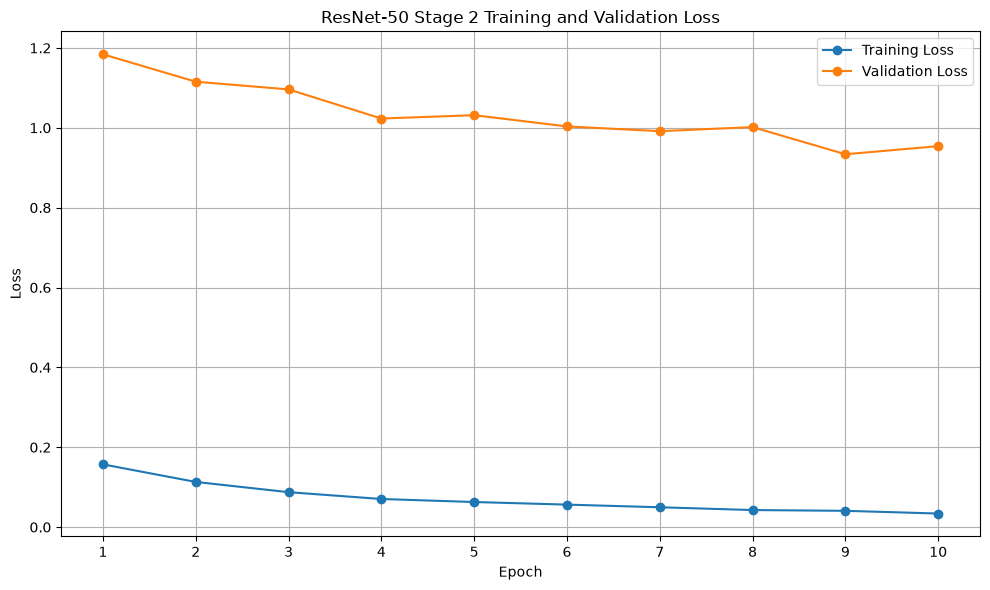

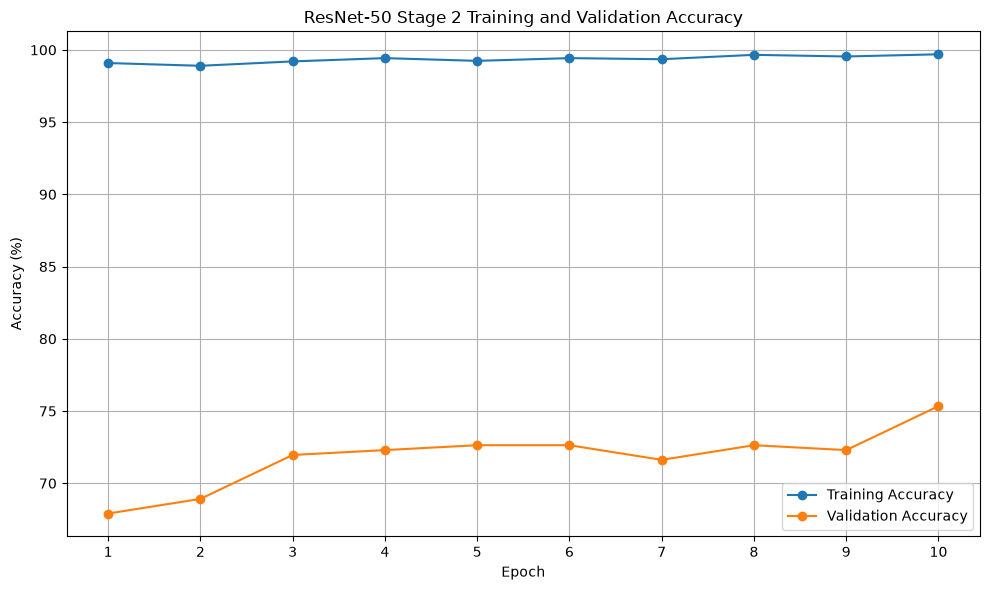

STAGE 2 TRAINING CURVES GENERATED


In [95]:
# STEP 11 — CELL 2
# Stage 2 Training Curves

import matplotlib.pyplot as plt

epochs_stage2 = range(1, len(stage2_history["train_loss"]) + 1)

# ==========================================
# 1. LOSS CURVE
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_stage2,
    stage2_history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_stage2,
    stage2_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-50 Stage 2 Training and Validation Loss")
plt.xticks(list(epochs_stage2))
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


# ==========================================
# 2. ACCURACY CURVE
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_stage2,
    [x * 100 for x in stage2_history["train_accuracy"]],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_stage2,
    [x * 100 for x in stage2_history["val_accuracy"]],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet-50 Stage 2 Training and Validation Accuracy")
plt.xticks(list(epochs_stage2))
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


print("STAGE 2 TRAINING CURVES GENERATED")

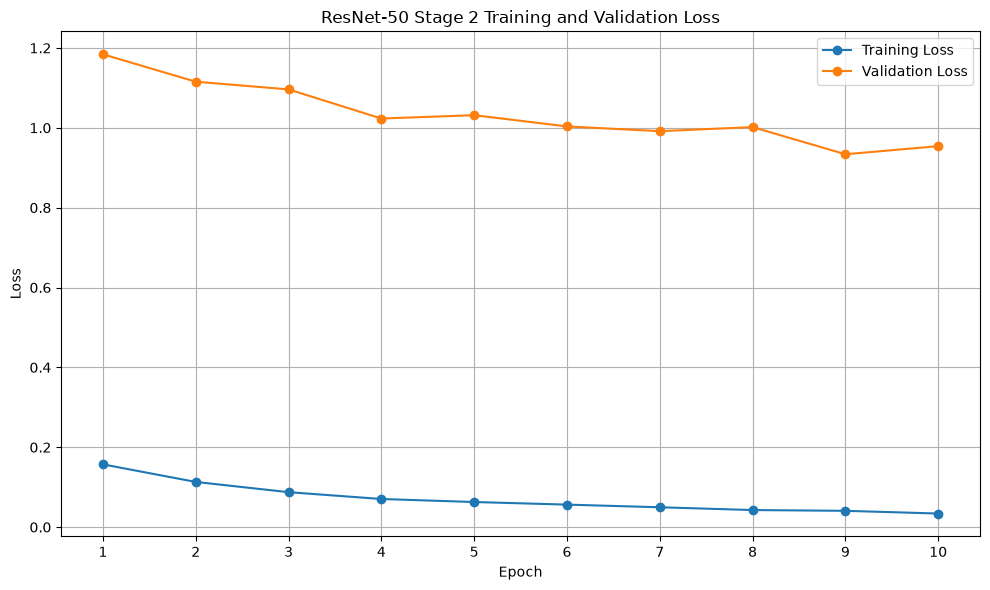

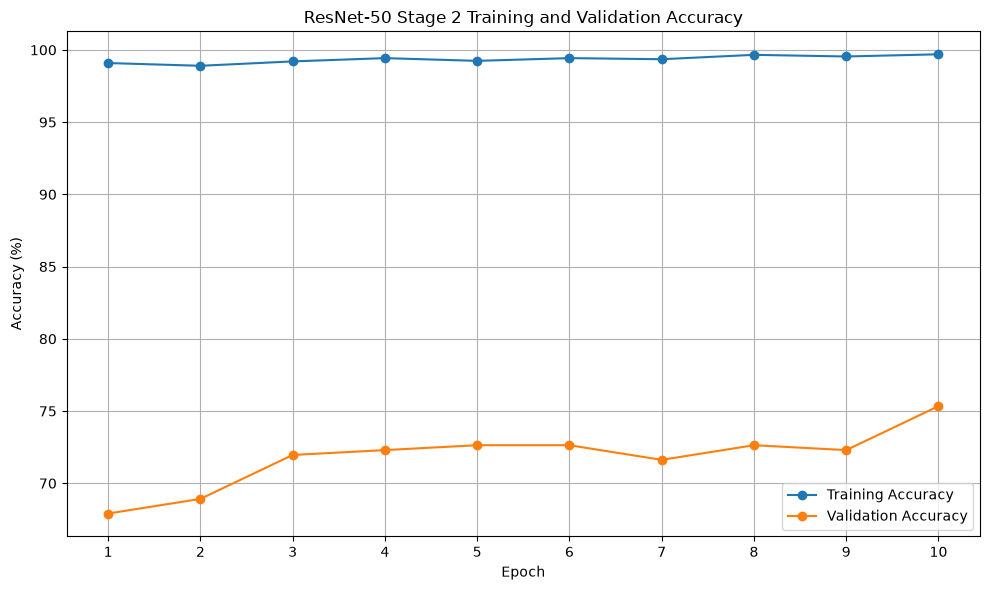

TRAINING CURVES SAVED
--------------------------------------------------
Loss curve:     c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\results\figures\stage2_training_validation_loss.png
Accuracy curve: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\results\figures\stage2_training_validation_accuracy.png

STAGE 2 FIGURE SAVE PASSED


In [96]:
# STEP 11 — CELL 3
# Save Stage 2 Training Curves

figures_dir = PROJECT_ROOT / "results" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# ==========================================
# 1. SAVE LOSS CURVE
# ==========================================

loss_curve_path = figures_dir / "stage2_training_validation_loss.png"

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_stage2,
    stage2_history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_stage2,
    stage2_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-50 Stage 2 Training and Validation Loss")
plt.xticks(list(epochs_stage2))
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()


# ==========================================
# 2. SAVE ACCURACY CURVE
# ==========================================

accuracy_curve_path = figures_dir / "stage2_training_validation_accuracy.png"

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_stage2,
    [x * 100 for x in stage2_history["train_accuracy"]],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_stage2,
    [x * 100 for x in stage2_history["val_accuracy"]],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet-50 Stage 2 Training and Validation Accuracy")
plt.xticks(list(epochs_stage2))
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(accuracy_curve_path, dpi=300, bbox_inches="tight")
plt.show()


# ==========================================
# VERIFY FILES
# ==========================================

print("TRAINING CURVES SAVED")
print("-" * 50)
print(f"Loss curve:     {loss_curve_path}")
print(f"Accuracy curve: {accuracy_curve_path}")

assert loss_curve_path.exists()
assert accuracy_curve_path.exists()

print("\nSTAGE 2 FIGURE SAVE PASSED")

In [98]:
# STEP 12 — CELL 1
# Find the saved ResNet-50 checkpoint

from pathlib import Path

print("=" * 60)
print("SEARCHING FOR SAVED MODEL CHECKPOINT")
print("=" * 60)

# Search the entire project for .pth files
pth_files = list(PROJECT_ROOT.rglob("*.pth"))

if len(pth_files) == 0:
    print("\nNO .pth FILES FOUND")
else:
    print(f"\nFound {len(pth_files)} .pth file(s):\n")

    for file_path in pth_files:
        print(file_path)

print("\n" + "=" * 60)

SEARCHING FOR SAVED MODEL CHECKPOINT

Found 2 .pth file(s):

c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\results\checkpoints\resnet50_stage1_best.pth
c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\.venv\Lib\site-packages\distutils-precedence.pth



In [99]:
# STEP 12 — CELL 2
# Save the Final Stage 2 Model Correctly

from pathlib import Path
import torch

# Make sure the model contains the BEST Stage 2 weights
model.load_state_dict(best_stage2_state)

# Final checkpoint directory
final_checkpoint_dir = (
    PROJECT_ROOT
    / "results"
    / "checkpoints"
    / "resnet50"
)

final_checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Final model path
final_model_path = (
    final_checkpoint_dir
    / "resnet50_stage2_best.pth"
)

# Save checkpoint
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "best_val_loss": best_stage2_val_loss,
        "best_val_accuracy": best_stage2_val_accuracy,
        "num_classes": NUM_CLASSES,
        "image_size": IMAGE_SIZE,
        "model_name": "ResNet-50",
        "trainable_blocks": ["layer4", "fc"],
        "layer4_learning_rate": STAGE2_LAYER4_LR,
        "fc_learning_rate": STAGE2_FC_LR,
        "weight_decay": STAGE2_WEIGHT_DECAY
    },
    final_model_path
)

print("=" * 60)
print("FINAL STAGE 2 MODEL SAVED")
print("=" * 60)

print(f"Path: {final_model_path}")
print(f"Best validation accuracy: {best_stage2_val_accuracy * 100:.2f}%")
print(f"Best validation loss: {best_stage2_val_loss:.6f}")

# Verify
assert final_model_path.exists()

file_size_mb = final_model_path.stat().st_size / (1024 ** 2)

print(f"File size: {file_size_mb:.2f} MB")
print("\nFINAL MODEL SAVE PASSED")

FINAL STAGE 2 MODEL SAVED
Path: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\results\checkpoints\resnet50\resnet50_stage2_best.pth
Best validation accuracy: 72.30%
Best validation loss: 0.933781
File size: 90.61 MB

FINAL MODEL SAVE PASSED


In [103]:
# STEP 12 — CELL 3
# Verify the Saved Stage 2 Checkpoint

import torch

print("=" * 60)
print("VERIFYING SAVED FINAL MODEL")
print("=" * 60)

# ---------------------------------------------------------
# 1. Load checkpoint from disk
# ---------------------------------------------------------
saved_checkpoint = torch.load(
    final_model_path,
    map_location=DEVICE
)

saved_val_accuracy = saved_checkpoint["best_val_accuracy"]
saved_val_loss = saved_checkpoint["best_val_loss"]

print("\nSaved checkpoint:")
print(f"Validation accuracy: {saved_val_accuracy * 100:.2f}%")
print(f"Validation loss:     {saved_val_loss:.6f}")


# ---------------------------------------------------------
# 2. Find BEST VALIDATION LOSS from current Stage 2 history
# ---------------------------------------------------------
best_loss_index = min(
    range(len(stage2_history["val_loss"])),
    key=lambda i: stage2_history["val_loss"][i]
)

history_best_loss = stage2_history["val_loss"][best_loss_index]
history_accuracy_at_best_loss = stage2_history["val_accuracy"][best_loss_index]

print("\nBest result in current Stage 2 history (by validation loss):")
print(f"Epoch:               {best_loss_index + 1}")
print(f"Validation accuracy: {history_accuracy_at_best_loss * 100:.2f}%")
print(f"Validation loss:     {history_best_loss:.6f}")


# ---------------------------------------------------------
# 3. Find BEST VALIDATION ACCURACY separately
# ---------------------------------------------------------
best_accuracy_index = max(
    range(len(stage2_history["val_accuracy"])),
    key=lambda i: stage2_history["val_accuracy"][i]
)

history_best_accuracy = stage2_history["val_accuracy"][best_accuracy_index]
loss_at_best_accuracy = stage2_history["val_loss"][best_accuracy_index]

print("\nBest result in current Stage 2 history (by validation accuracy):")
print(f"Epoch:               {best_accuracy_index + 1}")
print(f"Validation accuracy: {history_best_accuracy * 100:.2f}%")
print(f"Validation loss:     {loss_at_best_accuracy:.6f}")


# ---------------------------------------------------------
# 4. Verify checkpoint against BEST VALIDATION LOSS
# ---------------------------------------------------------
print("\n" + "=" * 60)
print("CHECKPOINT VERIFICATION")
print("=" * 60)

loss_matches = abs(saved_val_loss - history_best_loss) < 1e-6
accuracy_matches = abs(
    saved_val_accuracy - history_accuracy_at_best_loss
) < 1e-6

if loss_matches and accuracy_matches:
    print("CHECKPOINT MATCHES BEST VALIDATION-LOSS MODEL")
    print("Checkpoint verification PASSED")
else:
    print("WARNING: CHECKPOINT DOES NOT MATCH")
    print("Please inspect the Stage 2 training/checkpoint cells.")

print("=" * 60)

VERIFYING SAVED FINAL MODEL

Saved checkpoint:
Validation accuracy: 72.30%
Validation loss:     0.933781

Best result in current Stage 2 history (by validation loss):
Epoch:               9
Validation accuracy: 72.30%
Validation loss:     0.933781

Best result in current Stage 2 history (by validation accuracy):
Epoch:               10
Validation accuracy: 75.34%
Validation loss:     0.954023

CHECKPOINT VERIFICATION
CHECKPOINT MATCHES BEST VALIDATION-LOSS MODEL
Checkpoint verification PASSED


In [104]:
# STEP 12 — CELL 4
# Inspect the available Stage 2 best-model information

print("=" * 60)
print("CHECKING STAGE 2 BEST MODEL STATE")
print("=" * 60)

print("\n1. Best Stage 2 validation accuracy variable:")
print(best_stage2_val_accuracy)

print("\n2. Best Stage 2 validation loss variable:")
print(best_stage2_val_loss)

print("\n3. Best Stage 2 state:")
print(type(best_stage2_state))

print("\n4. Number of parameters stored in best_stage2_state:")
print(len(best_stage2_state))

print("\n5. Current model validation-related values from history:")

best_acc_index = max(
    range(len(stage2_history["val_accuracy"])),
    key=lambda i: stage2_history["val_accuracy"][i]
)

print(f"Best accuracy epoch: {best_acc_index + 1}")
print(
    f"Best accuracy: "
    f"{stage2_history['val_accuracy'][best_acc_index] * 100:.2f}%"
)
print(
    f"Loss at best accuracy epoch: "
    f"{stage2_history['val_loss'][best_acc_index]:.6f}"
)

print("\n" + "=" * 60)

CHECKING STAGE 2 BEST MODEL STATE

1. Best Stage 2 validation accuracy variable:
0.722972972972973

2. Best Stage 2 validation loss variable:
0.9337809150283402

3. Best Stage 2 state:
<class 'dict'>

4. Number of parameters stored in best_stage2_state:
320

5. Current model validation-related values from history:
Best accuracy epoch: 10
Best accuracy: 75.34%
Loss at best accuracy epoch: 0.954023



In [105]:
# STEP 12 — CELL 5
# Check available Stage 2 model states

print("=" * 60)
print("CHECKING AVAILABLE MODEL STATES")
print("=" * 60)

print("\nStage 2 history:")
for i in range(len(stage2_history["val_accuracy"])):
    print(
        f"Epoch {i+1:02d} | "
        f"Train Acc: {stage2_history['train_accuracy'][i]*100:.2f}% | "
        f"Val Acc: {stage2_history['val_accuracy'][i]*100:.2f}% | "
        f"Val Loss: {stage2_history['val_loss'][i]:.6f}"
    )

print("\nCurrent best variables:")
print(f"best_stage2_val_accuracy = {best_stage2_val_accuracy:.6f}")
print(f"best_stage2_val_loss     = {best_stage2_val_loss:.6f}")

print("\nBest-state object:")
print(f"type = {type(best_stage2_state)}")
print(f"parameters = {len(best_stage2_state)}")

print("\nCurrent model object:")
print(type(model))

print("=" * 60)

CHECKING AVAILABLE MODEL STATES

Stage 2 history:
Epoch 01 | Train Acc: 99.09% | Val Acc: 67.91% | Val Loss: 1.184125
Epoch 02 | Train Acc: 98.90% | Val Acc: 68.92% | Val Loss: 1.115516
Epoch 03 | Train Acc: 99.20% | Val Acc: 71.96% | Val Loss: 1.096220
Epoch 04 | Train Acc: 99.43% | Val Acc: 72.30% | Val Loss: 1.023256
Epoch 05 | Train Acc: 99.24% | Val Acc: 72.64% | Val Loss: 1.031631
Epoch 06 | Train Acc: 99.43% | Val Acc: 72.64% | Val Loss: 1.003426
Epoch 07 | Train Acc: 99.36% | Val Acc: 71.62% | Val Loss: 0.991592
Epoch 08 | Train Acc: 99.66% | Val Acc: 72.64% | Val Loss: 1.001771
Epoch 09 | Train Acc: 99.55% | Val Acc: 72.30% | Val Loss: 0.933781
Epoch 10 | Train Acc: 99.70% | Val Acc: 75.34% | Val Loss: 0.954023

Current best variables:
best_stage2_val_accuracy = 0.722973
best_stage2_val_loss     = 0.933781

Best-state object:
type = <class 'dict'>
parameters = 320

Current model object:
<class 'torchvision.models.resnet.ResNet'>


In [107]:
# FINAL RESULTS FILE VERIFICATION

import json
from pathlib import Path

baseline_path = Path(
    "results/evaluation/stage2_baseline_results.json"
)

with open(baseline_path, "r") as f:
    results = json.load(f)

print("=" * 60)
print("FINAL BASELINE RESULTS")
print("=" * 60)

print(f"Model:                  {results['model']}")
print(f"Stage:                  {results['stage']}")
print(f"Test samples:           {results['test_samples']}")
print(f"Test accuracy:          {results['test_accuracy_percent']:.2f}%")
print(f"Test loss:              {results['test_loss']:.6f}")

print("\nStage 2 checkpoint:")
print(f"Best epoch by val loss: {results['stage2_best_epoch_by_val_loss']}")
print(
    f"Val accuracy:           "
    f"{results['stage2_best_val_accuracy'] * 100:.2f}%"
)
print(
    f"Val loss:               "
    f"{results['stage2_best_val_loss']:.6f}"
)

print("\nHighest validation accuracy:")
print(f"Epoch:                  {results['stage2_best_accuracy_epoch']}")
print(
    f"Accuracy:               "
    f"{results['stage2_highest_val_accuracy'] * 100:.2f}%"
)

print("=" * 60)
print("FINAL RESULTS FILE VERIFICATION PASSED")
print("=" * 60)

FINAL BASELINE RESULTS
Model:                  ResNet-50
Stage:                  Stage 2 fine-tuning
Test samples:           2485
Test accuracy:          73.72%
Test loss:              0.879393

Stage 2 checkpoint:
Best epoch by val loss: 9
Val accuracy:           72.30%
Val loss:               0.933781

Highest validation accuracy:
Epoch:                  10
Accuracy:               75.34%
FINAL RESULTS FILE VERIFICATION PASSED
